# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 09     |  |
| :-------------|:-------------|
| Christoph Smit| 6494056 |
| Shannon Werleman| 6292933 |
| Casper Jansen| 6265200 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['ChristophSmit', 'ShannonWerleman','CasperJansen']

## Opdracht 1: Planning.

| Planning Groep: 09     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie + Testmeting | 12:00 af |
| Eerste Iteratie | 12:30 af |
| Algoritme af en getest| 16:30 |
| Opruimen en feedback klaar| 17:00 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [09]
<img src="kalibratie.jpg" width="400">

0.03468600361233243 -0.28257771589955416


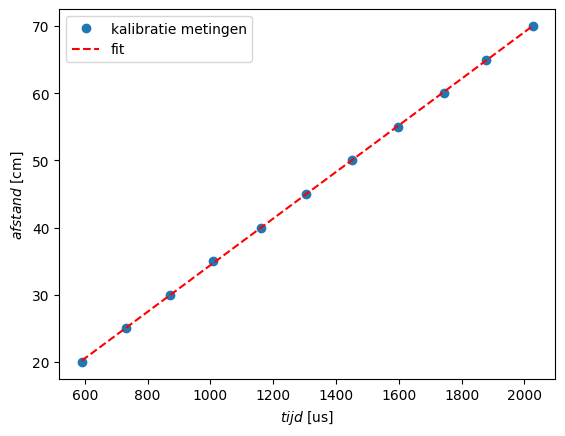

In [43]:
# verwerk hier jullie kalibratiemetingen
tijd = np.array([1180, 1460, 1743, 2016, 2320, 2610, 2903, 3195, 3490, 3752, 4052])/2
afstand = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])

def fit(x, a, b):
    return a * x + b

popt,pcov = curve_fit(fit, tijd, afstand)

a = popt[0]
b = popt[1]

xtest = np.linspace(np.min(tijd), np.max(tijd), 1000)
ytest = fit(xtest, a, b)


plt.plot(tijd, afstand, 'o', label='kalibratie metingen')
plt.plot(xtest, ytest, 'r--', label='fit')
plt.xlabel('$tijd$ [us]')
plt.ylabel('$afstand$ [cm]')
plt.legend()
print(a,b)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  41.64
1   0  30   0  20  41.12
2  40   0  30   0  40.16
3  30   0  20   0  39.78


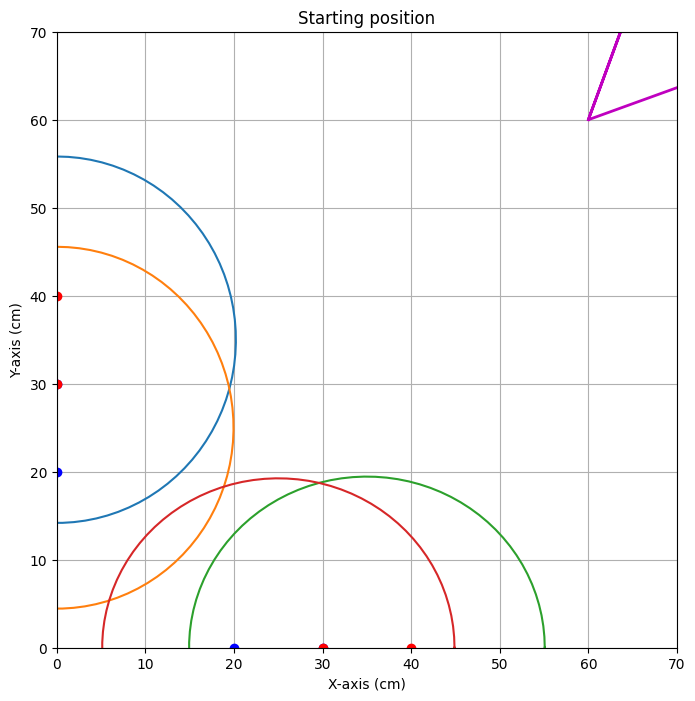


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.280


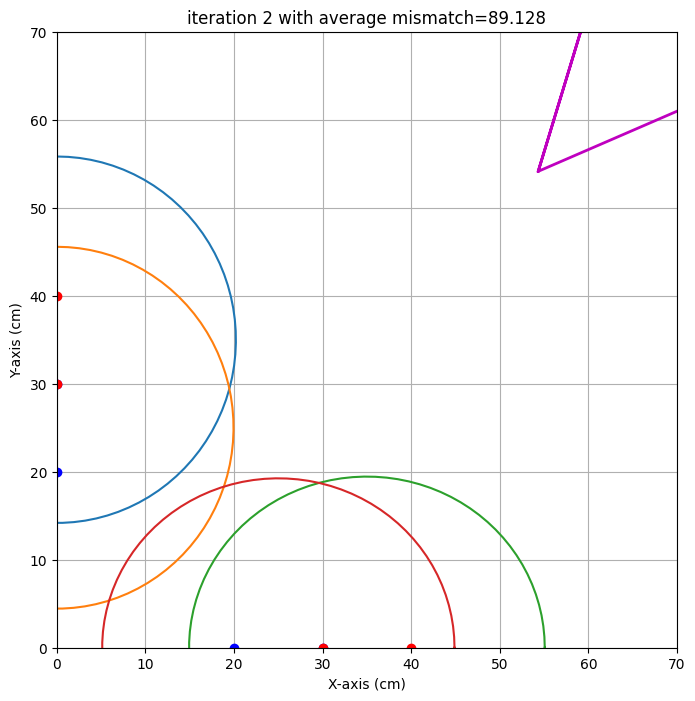

end iteration 2 with average mismatch=89.128


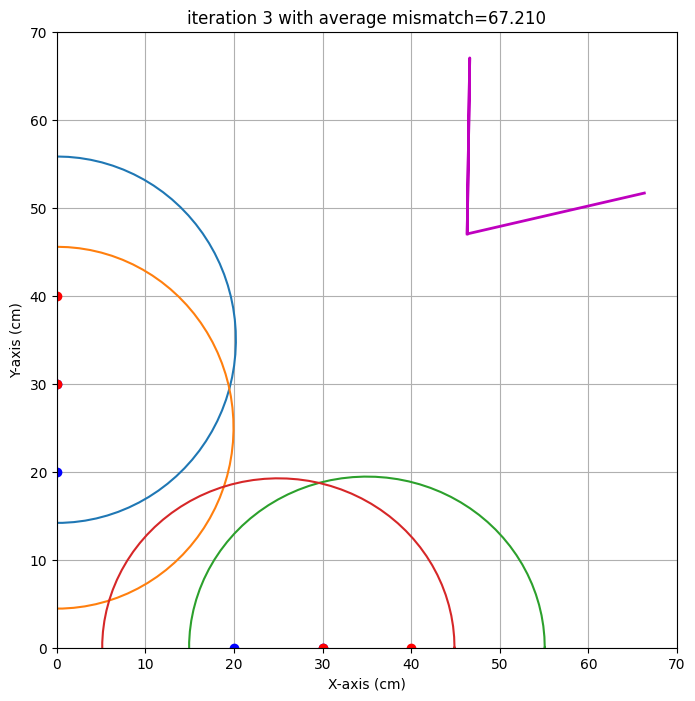

end iteration 3 with average mismatch=67.210


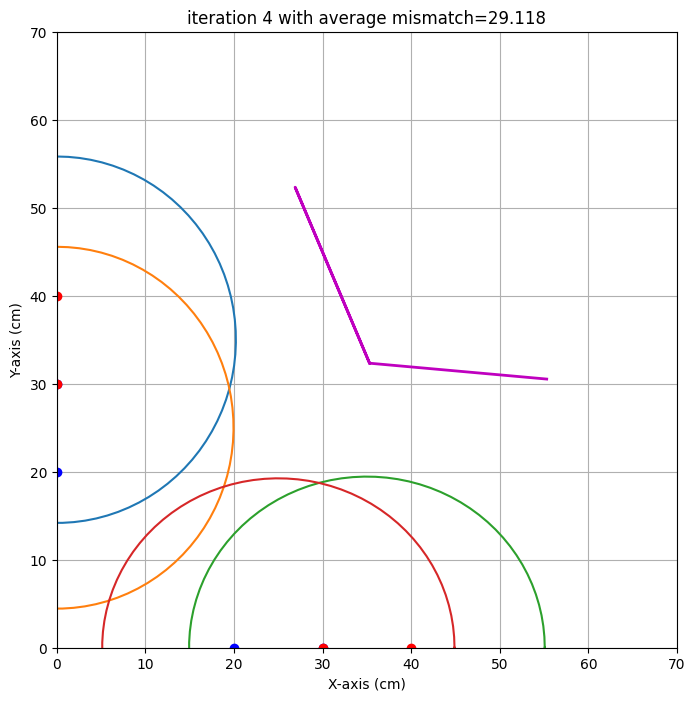

end iteration 4 with average mismatch=29.118


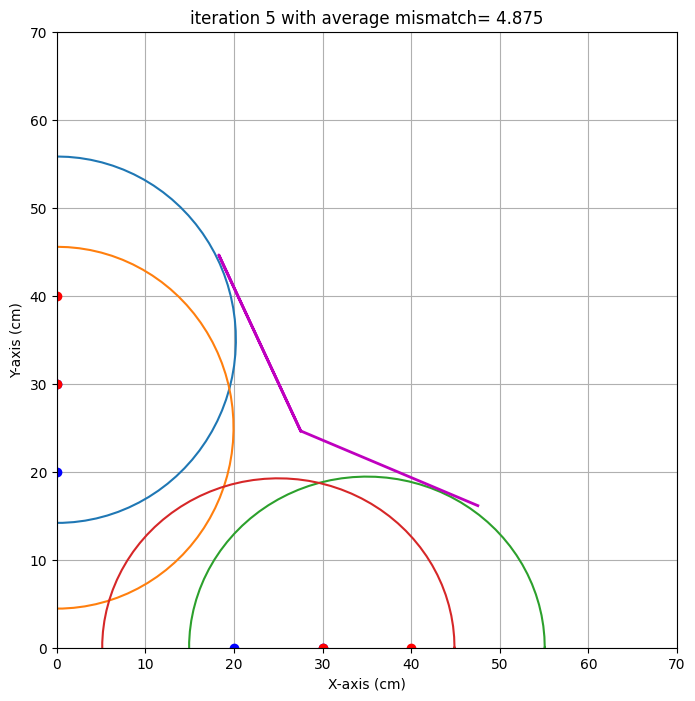

end iteration 5 with average mismatch= 4.875


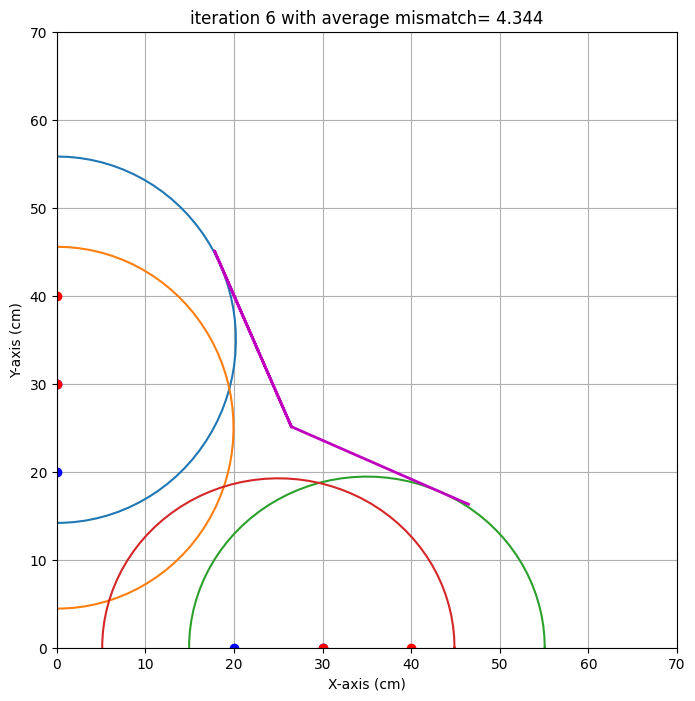

end iteration 6 with average mismatch= 4.344
end iteration 7 with average mismatch= 3.930


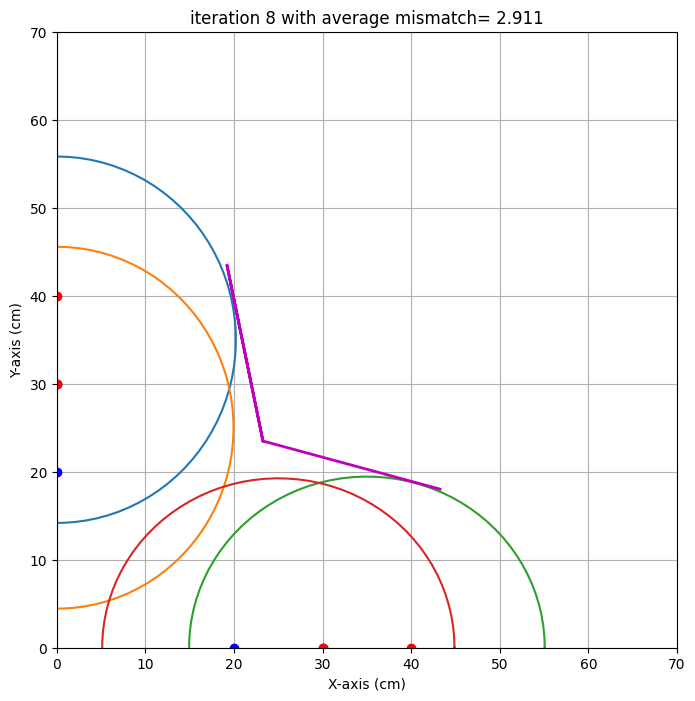

end iteration 8 with average mismatch= 2.911


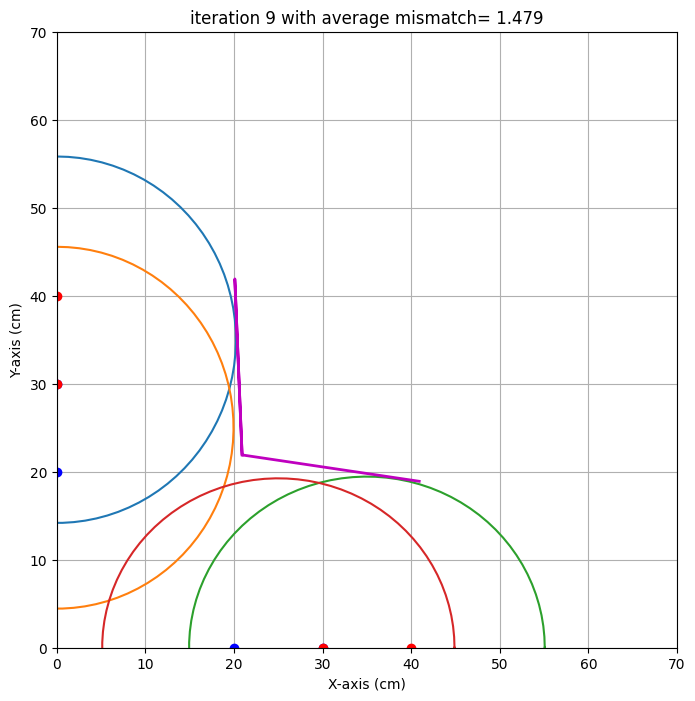

end iteration 9 with average mismatch= 1.479


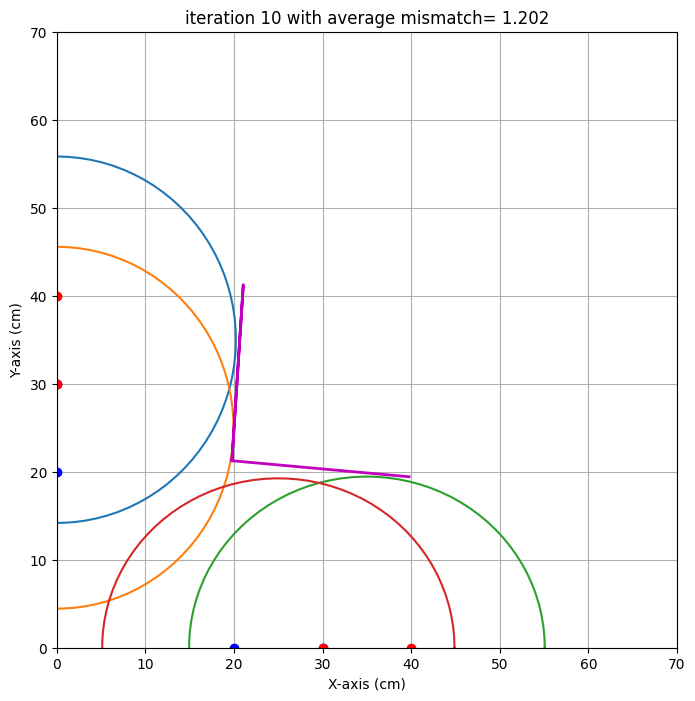

end iteration 10 with average mismatch= 1.202


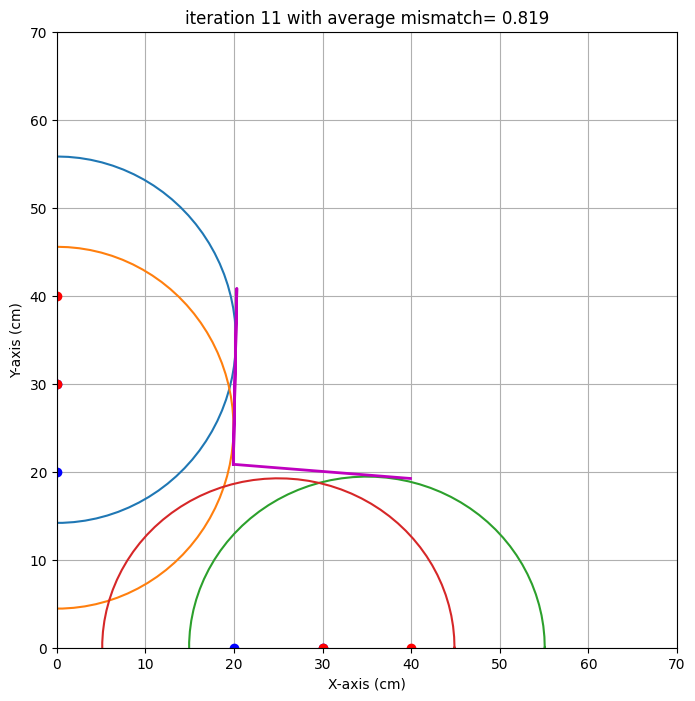

end iteration 11 with average mismatch= 0.819
end iteration 12 with average mismatch= 0.807


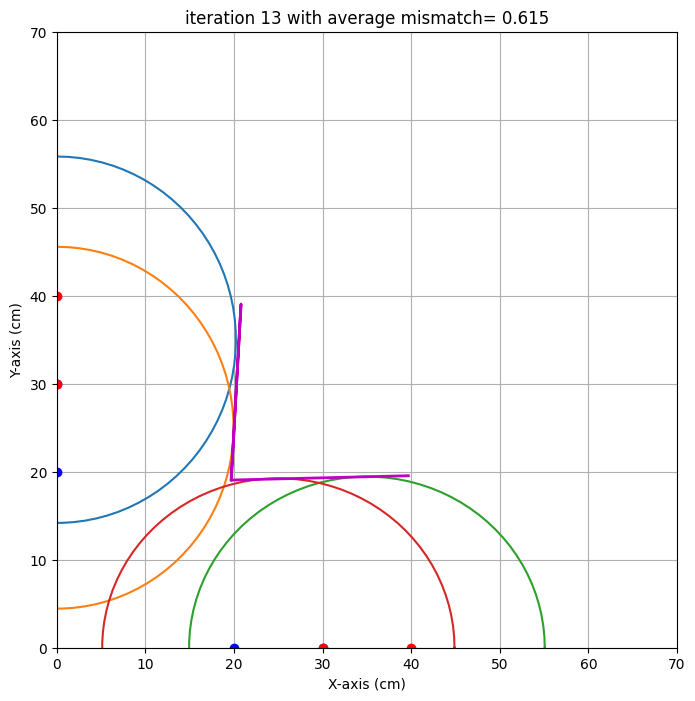

end iteration 13 with average mismatch= 0.615


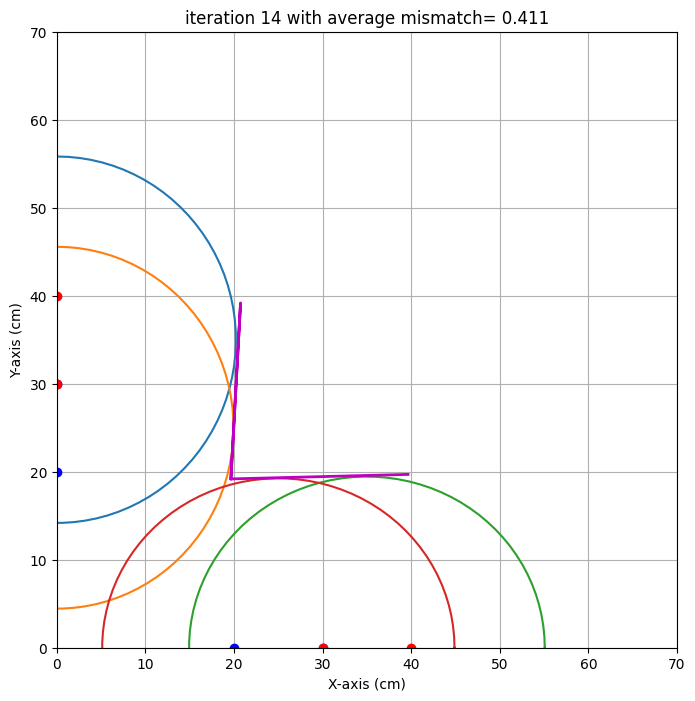

end iteration 14 with average mismatch= 0.411
end iteration 15 with average mismatch= 0.386
end iteration 16 with average mismatch= 0.385
end iteration 17 with average mismatch= 0.384


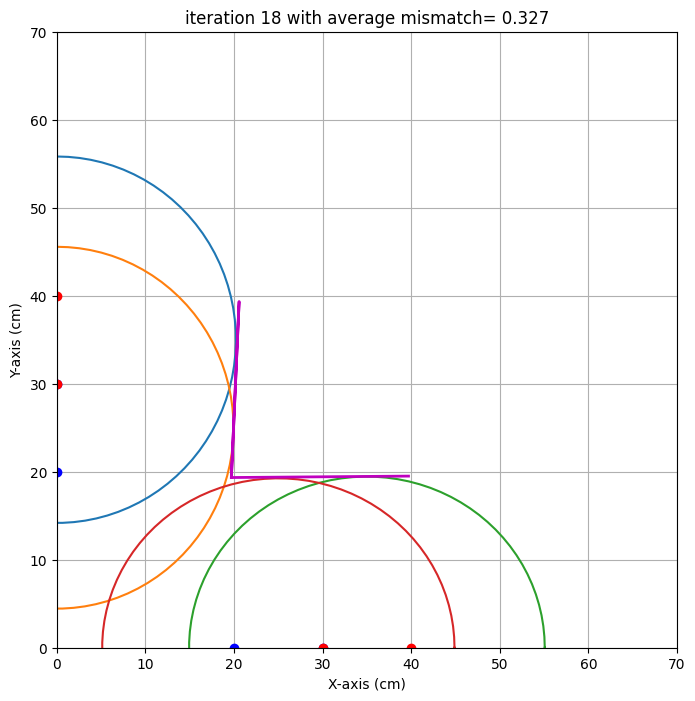

end iteration 18 with average mismatch= 0.327
end iteration 19 with average mismatch= 0.310
end iteration 20 with average mismatch= 0.310
end iteration 21 with average mismatch= 0.310
end iteration 22 with average mismatch= 0.310
end iteration 23 with average mismatch= 0.310
end iteration 24 with average mismatch= 0.280
end iteration 25 with average mismatch= 0.260


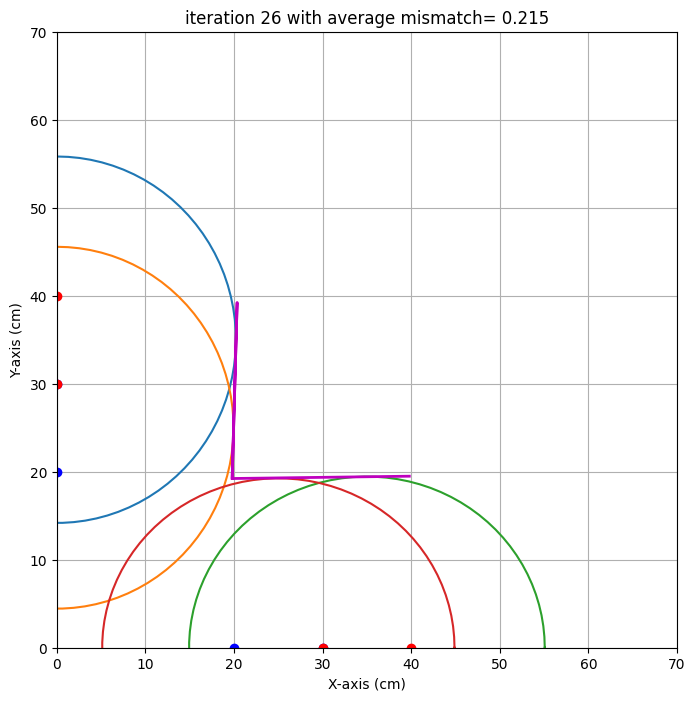

end iteration 26 with average mismatch= 0.215
end iteration 27 with average mismatch= 0.215
end iteration 28 with average mismatch= 0.215
end iteration 29 with average mismatch= 0.215
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.215
###############################################################################
end of iteration  30
Best alpha=   0.75 with uncertainty=   1.79
Best beta =   1.61 with uncertainty=   1.55
Best x0   =  19.79 with uncertainty=   0.27
Best y0   =  19.23 with uncertainty=   0.58
###############################################################################


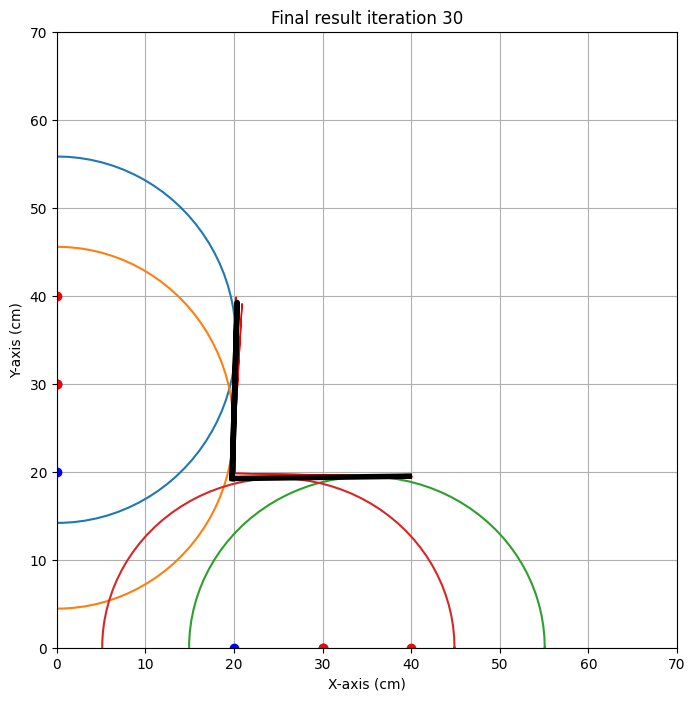

In [44]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.64],
    [0,30,0,20,41.12],
    #[0,10,0,20,130.0],
    [40,0,30,0,40.16],
    [30,0,20,0,39.78],
    #[10,0,20,0,120.0],
    #[10,0,0,10,129.34]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [45]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.8 cm met een standaardafwijking van 0.3 cm 
y0: 19.2 cm met een standaardafwijking van 0.6 cm 
alpha: 0.8 graden met een standaardafwijking van 1.8 graad 
beta: 1.6 graden met een standaardafwijking van 1.6 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Christoph]

<img src="algoritmechristoph.jpeg" width="400">

#### algoritme [Shannon]

<img src="Algoritme.jpeg" width="400">

#### algoritme [Casper]

<img src="algorcasper.jpeg" width="400">

## Opdracht 6: Test iteratie 0.

In [46]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35.5,
           'y0':41.9,
           'alpha' : 7,
           'beta' : 0
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={ studentNames[1] :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,20,0,30,ongeldig],
    [0,70,0,60,70.23],
    [0,50,0,60,69.05],
    #[20,0,30,0,ongeldig],
    #[70,0,60,0,ongeldig],
    [40,0,50,0, 86.70],
    [45,0,55,0,88.31]
    ]),
       studentNames[0] : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,69.95],
    [0,65,0,55,69.39],
    [0,60,0,50,70.05],
    [0,55,0,45,69.95],
    [0,50,0,40,69.60],
    [0,45,0,35,73.50],
    # [0,40,0,30,ongeldig],
    [70,0,60,0,95.32],
    [65,0,55,0,92.57],
    [60,0,50,0,91.80],
    [55,0,45,0,89.83],
    [50,0,40,0,89.80],
    [45,0,35,0,92.98]
    #[40,0,30,0,ongeldig]
    ]),
       studentNames[2] : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
         [70,0,60,0,97.50],
         [0,49,0,59,70.3],
         [0,59,0,69,69.50],
         [0,39,0,49,69.85],
         [60,0,50,0,93.06]  
       ])
   
   }

## Opdracht 7: Evaluatie.

ChristophSmit
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0    0  70   0  60  69.95
1    0  65   0  55  69.39
2    0  60   0  50  70.05
3    0  55   0  45  69.95
4    0  50   0  40  69.60
5    0  45   0  35  73.50
6   70   0  60   0  95.32
7   65   0  55   0  92.57
8   60   0  50   0  91.80
9   55   0  45   0  89.83
10  50   0  40   0  89.80
11  45   0  35   0  92.98


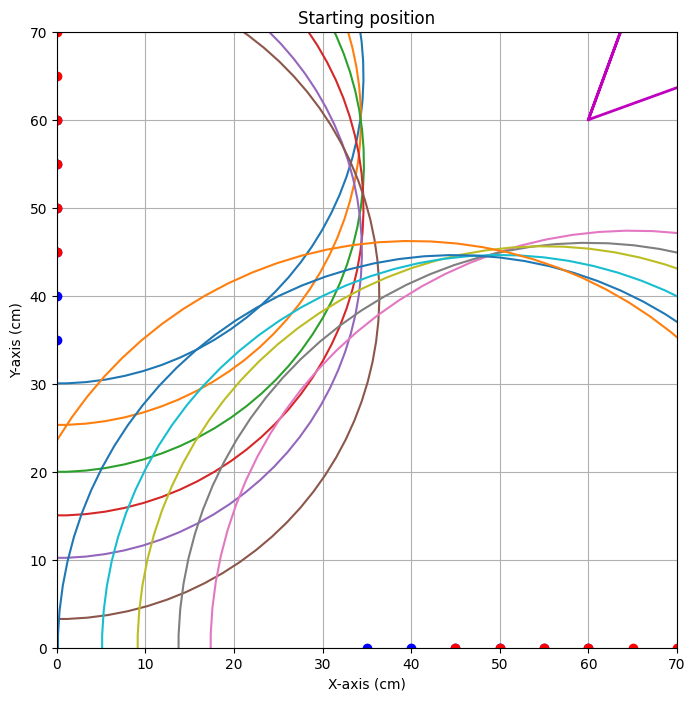


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.168


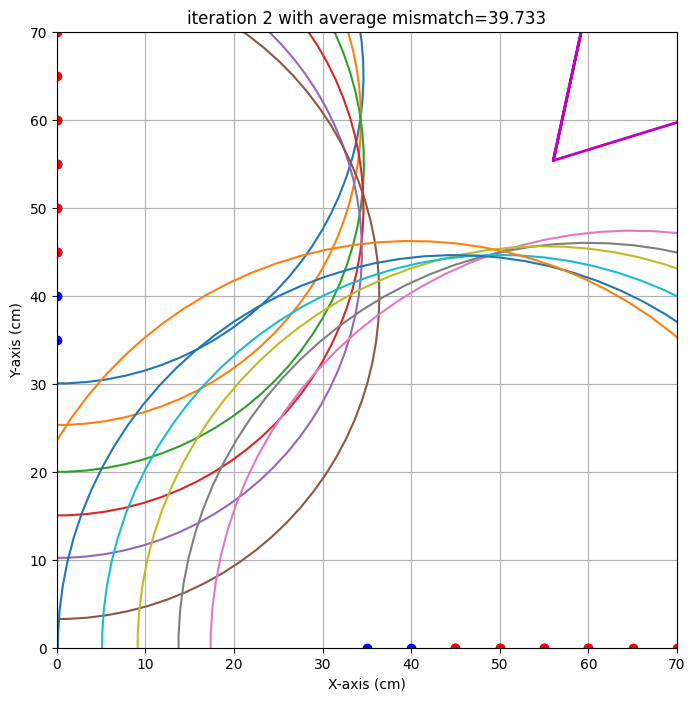

end iteration 2 with average mismatch=39.733


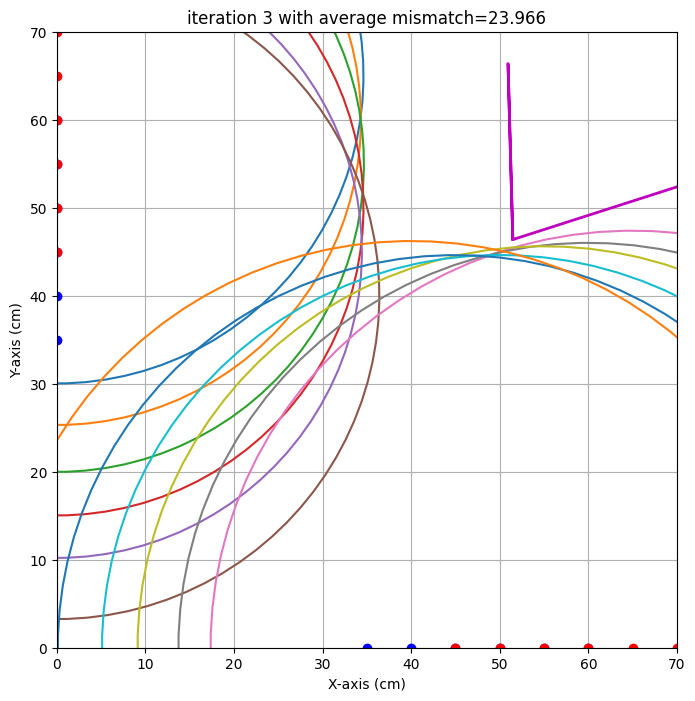

end iteration 3 with average mismatch=23.966


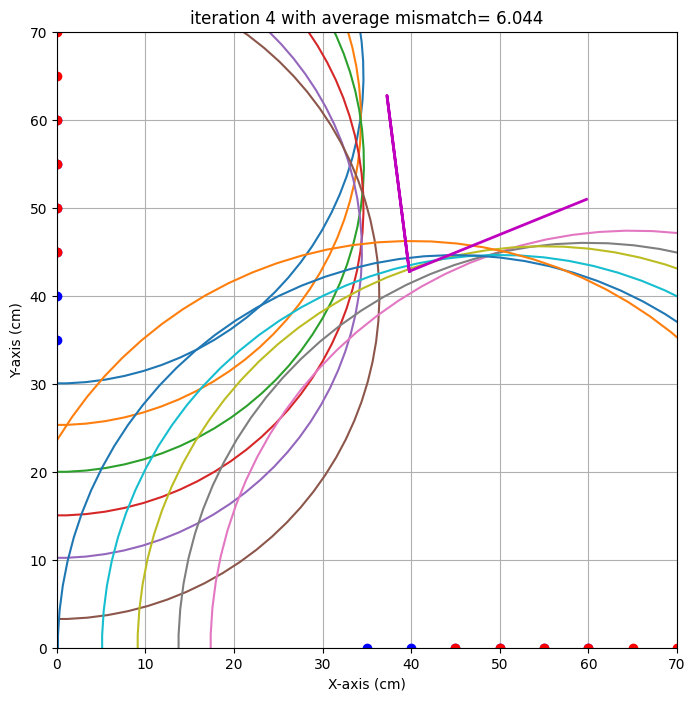

end iteration 4 with average mismatch= 6.044


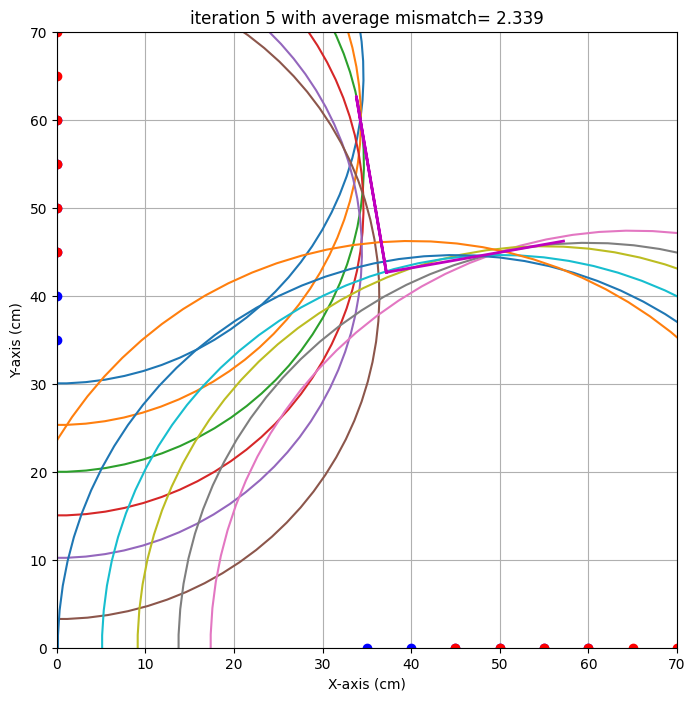

end iteration 5 with average mismatch= 2.339


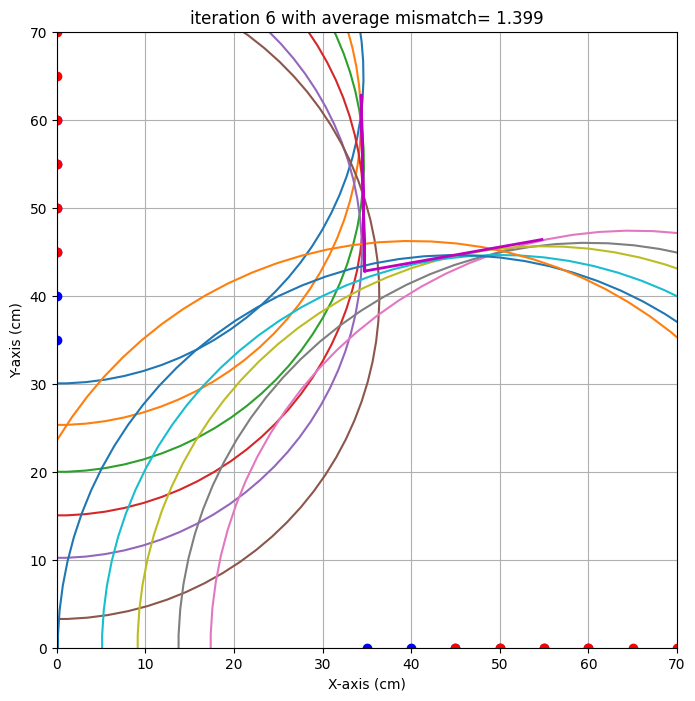

end iteration 6 with average mismatch= 1.399
end iteration 7 with average mismatch= 1.387
end iteration 8 with average mismatch= 1.300
end iteration 9 with average mismatch= 1.298
end iteration 10 with average mismatch= 1.229
end iteration 11 with average mismatch= 1.228
end iteration 12 with average mismatch= 1.228
end iteration 13 with average mismatch= 1.228
end iteration 14 with average mismatch= 1.228
end iteration 15 with average mismatch= 1.228
end iteration 16 with average mismatch= 1.228
end iteration 17 with average mismatch= 1.228
end iteration 18 with average mismatch= 1.228
end iteration 19 with average mismatch= 1.228
end iteration 20 with average mismatch= 1.228
end iteration 21 with average mismatch= 1.228
end iteration 22 with average mismatch= 1.228
end iteration 23 with average mismatch= 1.228
end iteration 24 with average mismatch= 1.228
end iteration 25 with average mismatch= 1.228
end iteration 26 with average mismatch= 1.228
end iteration 27 with average mismatch

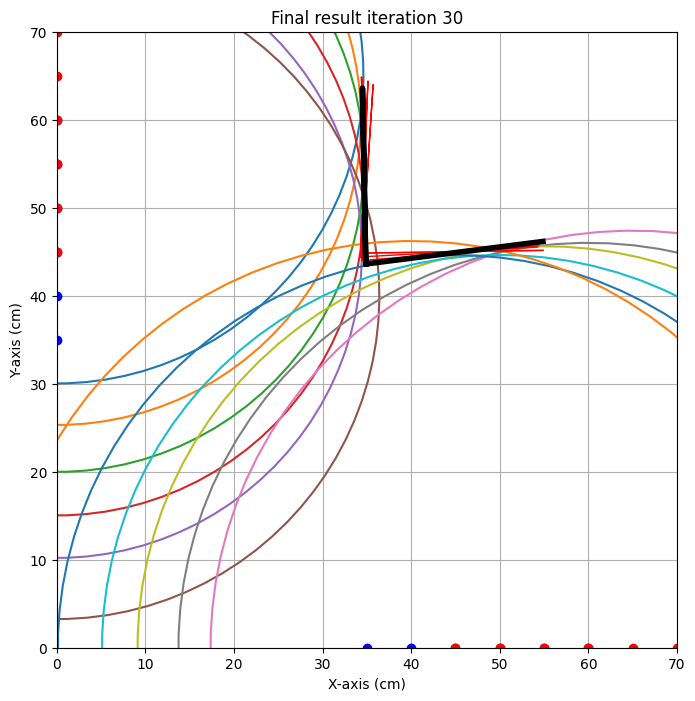

{'alpha': np.float64(7.290602960342084), 'alpha_eps': np.float64(6.4166127900692365), 'beta': np.float64(-1.0757127509998923), 'beta_eps': np.float64(4.761568091559634), 'x0': np.float64(34.87306998861857), 'x0_eps': np.float64(0.6053359019494593), 'y0': np.float64(43.60724903424884), 'y0_eps': np.float64(1.2409728709895944)}
ShannonWerleman
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  70.23
1   0  50   0  60  69.05
2  40   0  50   0  86.70
3  45   0  55   0  88.31


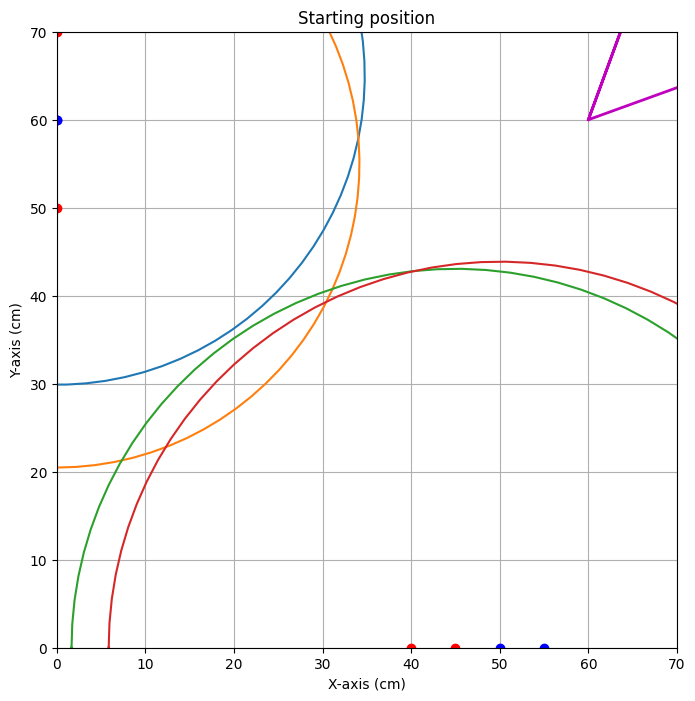


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.764


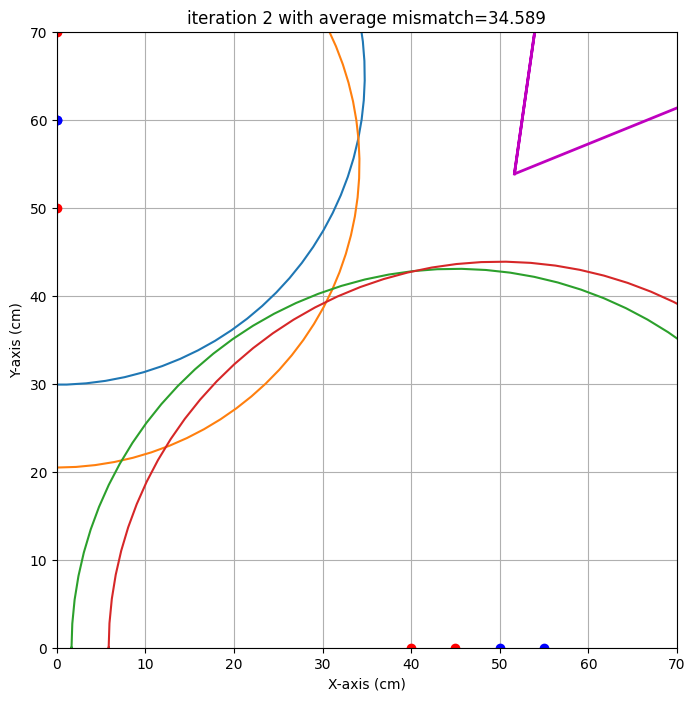

end iteration 2 with average mismatch=34.589


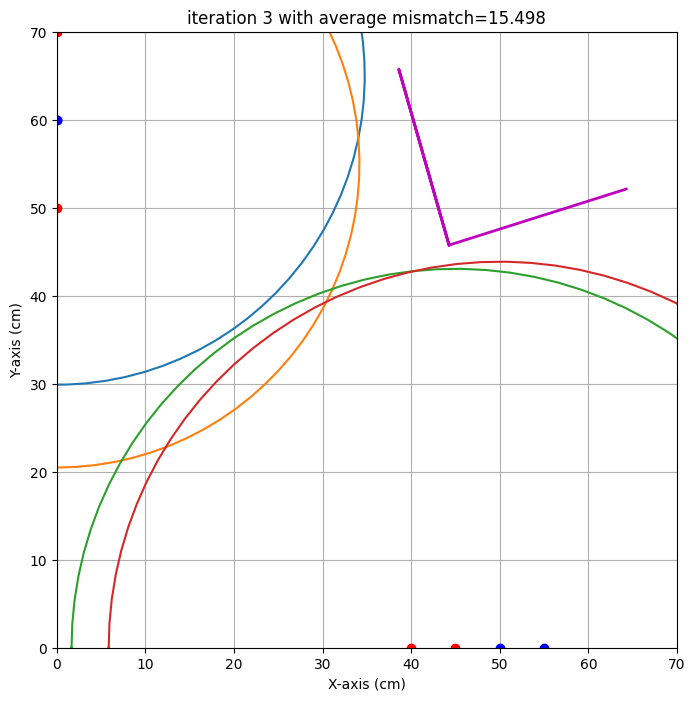

end iteration 3 with average mismatch=15.498


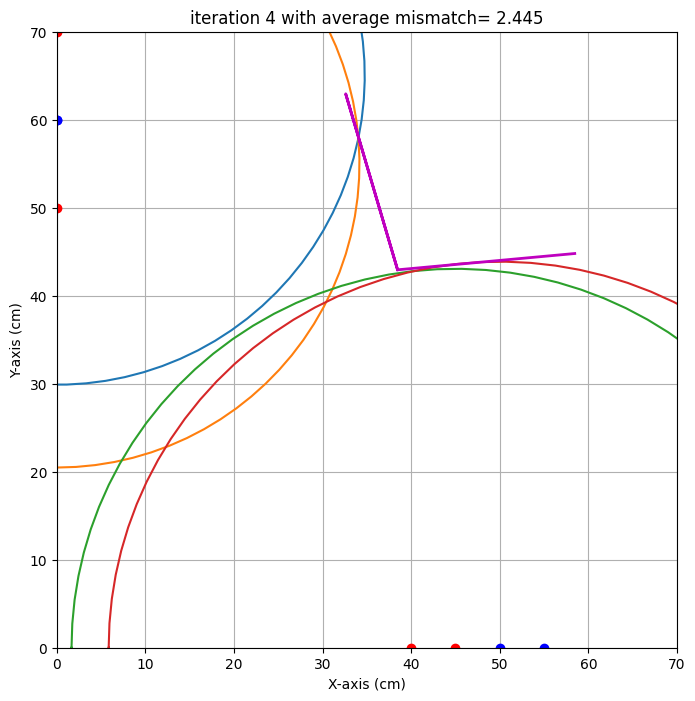

end iteration 4 with average mismatch= 2.445


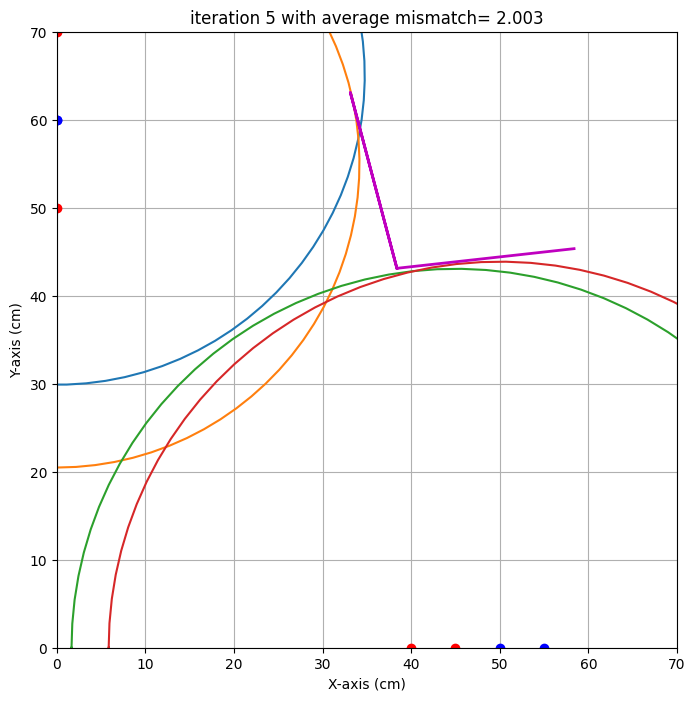

end iteration 5 with average mismatch= 2.003


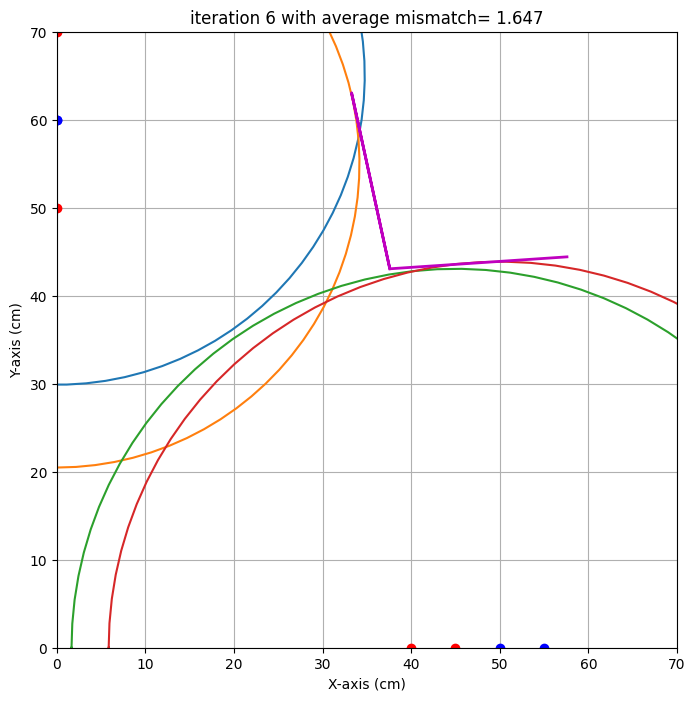

end iteration 6 with average mismatch= 1.647


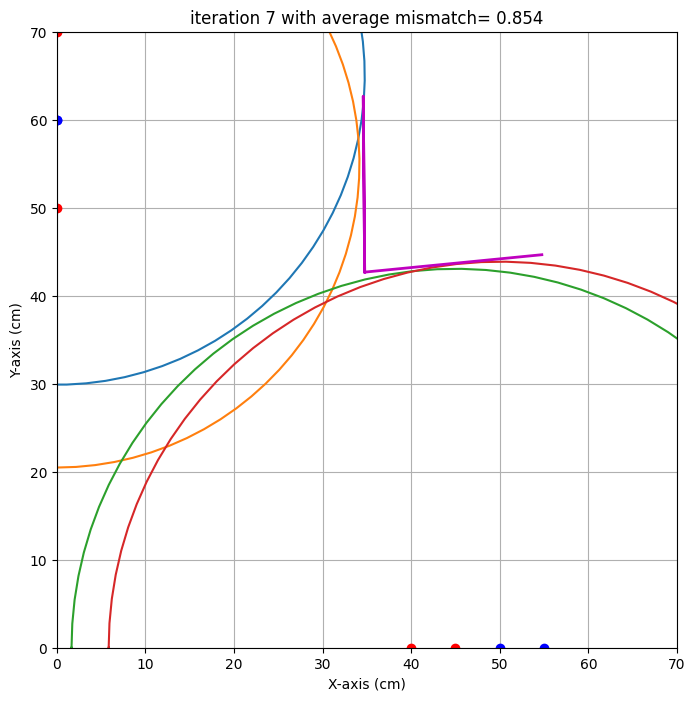

end iteration 7 with average mismatch= 0.854


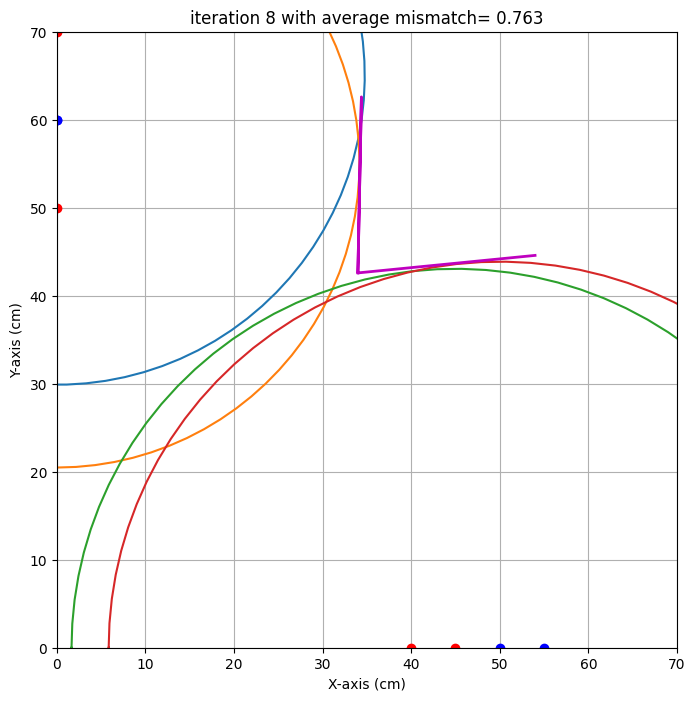

end iteration 8 with average mismatch= 0.763


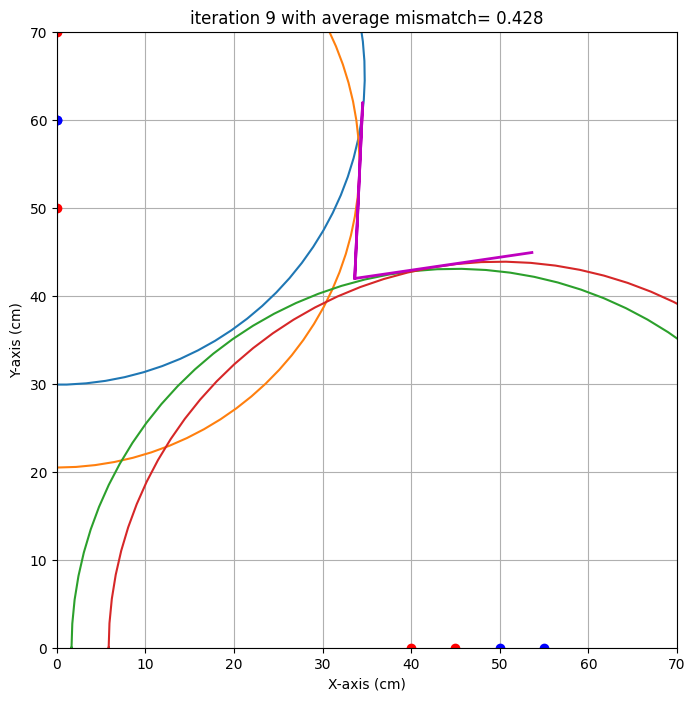

end iteration 9 with average mismatch= 0.428
end iteration 10 with average mismatch= 0.413
end iteration 11 with average mismatch= 0.407
end iteration 12 with average mismatch= 0.396
end iteration 13 with average mismatch= 0.396
end iteration 14 with average mismatch= 0.396
end iteration 15 with average mismatch= 0.396
end iteration 16 with average mismatch= 0.396
end iteration 17 with average mismatch= 0.396
end iteration 18 with average mismatch= 0.396
end iteration 19 with average mismatch= 0.396
end iteration 20 with average mismatch= 0.396
end iteration 21 with average mismatch= 0.383
end iteration 22 with average mismatch= 0.383
end iteration 23 with average mismatch= 0.383
end iteration 24 with average mismatch= 0.383
end iteration 25 with average mismatch= 0.383
end iteration 26 with average mismatch= 0.383
end iteration 27 with average mismatch= 0.383
end iteration 28 with average mismatch= 0.383
end iteration 29 with average mismatch= 0.383
Last iteration, also determine unce

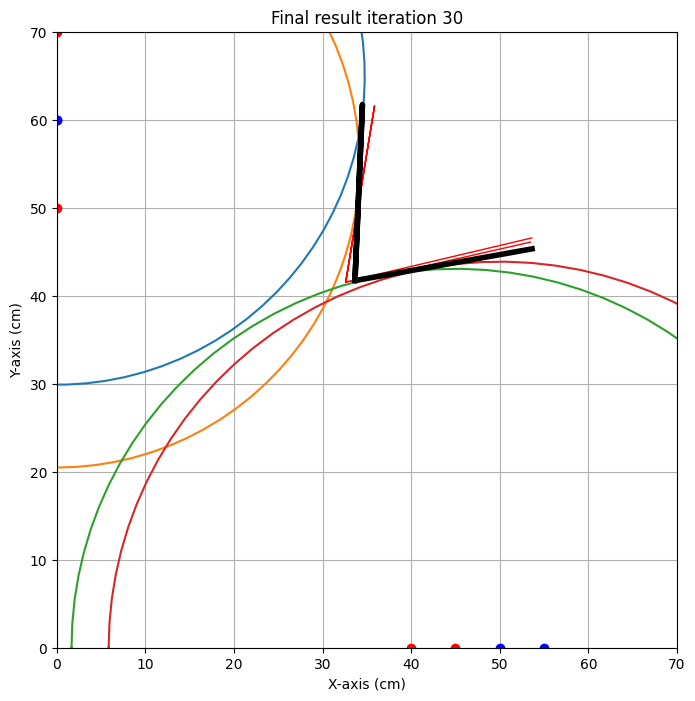

{'alpha': np.float64(10.228433401569097), 'alpha_eps': np.float64(3.140121276108383), 'beta': np.float64(2.4104522635991366), 'beta_eps': np.float64(6.823484811888683), 'x0': np.float64(33.65261389847684), 'x0_eps': np.float64(1.0402394640802015), 'y0': np.float64(41.718166460064424), 'y0_eps': np.float64(0.19342177391321513)}
CasperJansen
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  60   0  97.50
1   0  49   0  59  70.30
2   0  59   0  69  69.50
3   0  39   0  49  69.85
4  60   0  50   0  93.06


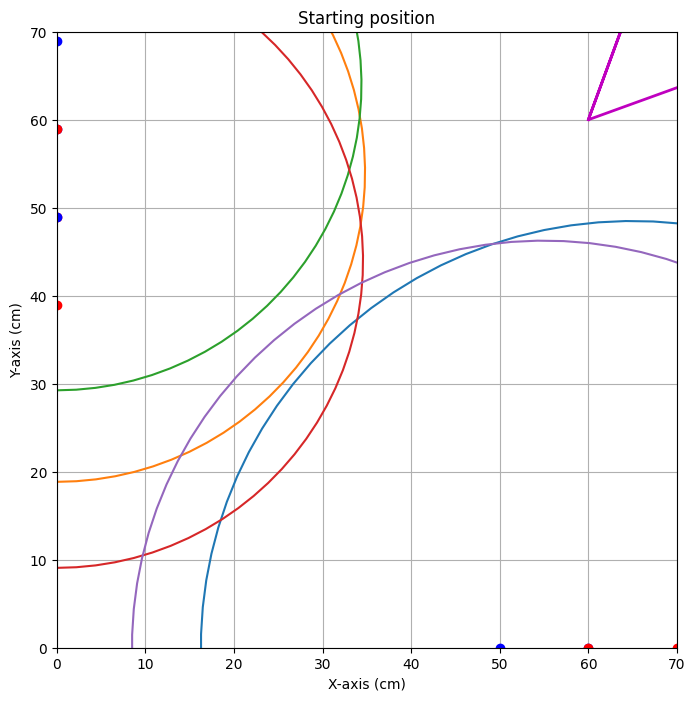


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=46.606


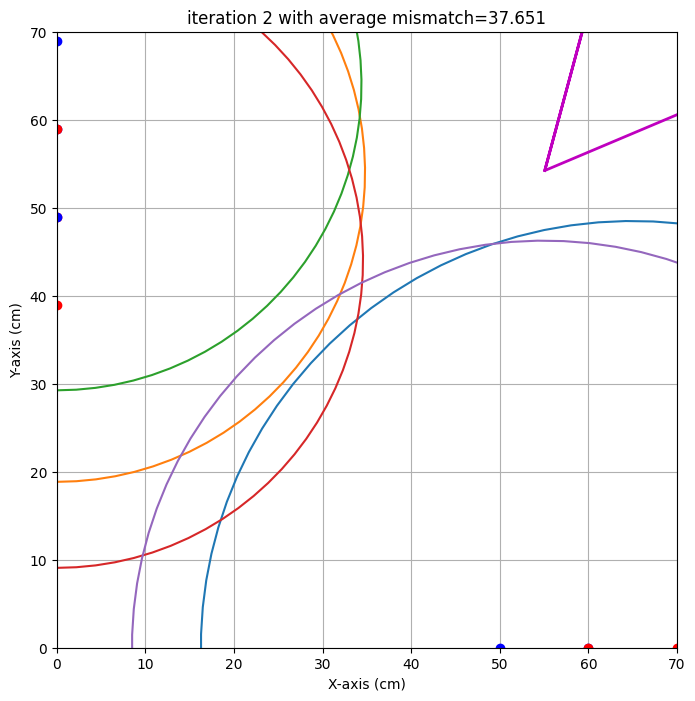

end iteration 2 with average mismatch=37.651


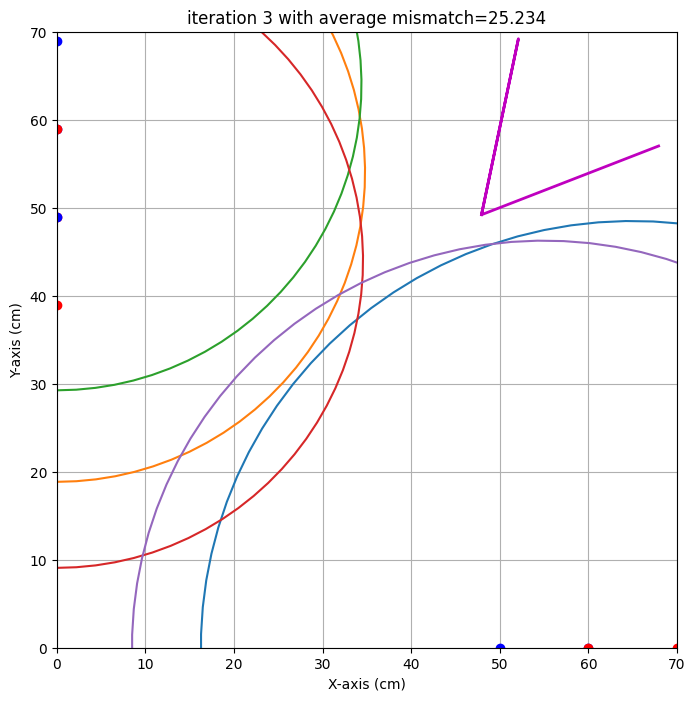

end iteration 3 with average mismatch=25.234


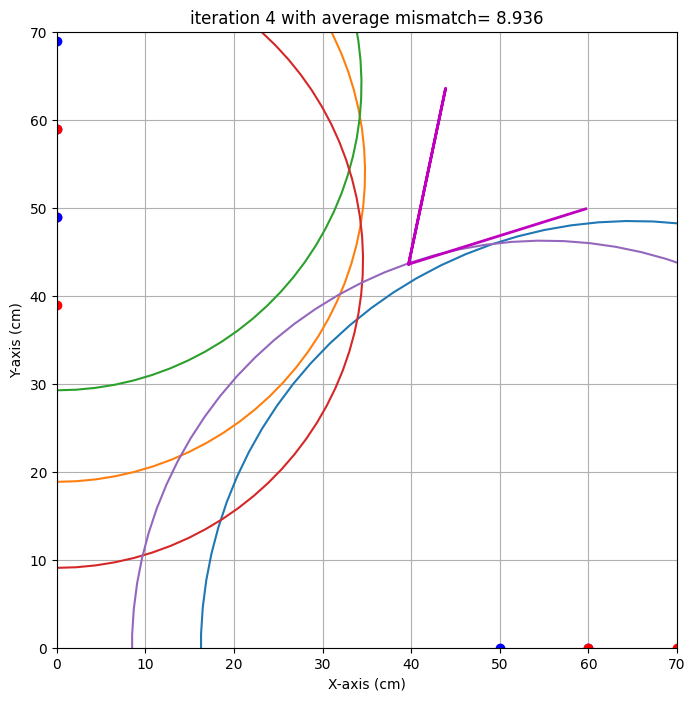

end iteration 4 with average mismatch= 8.936


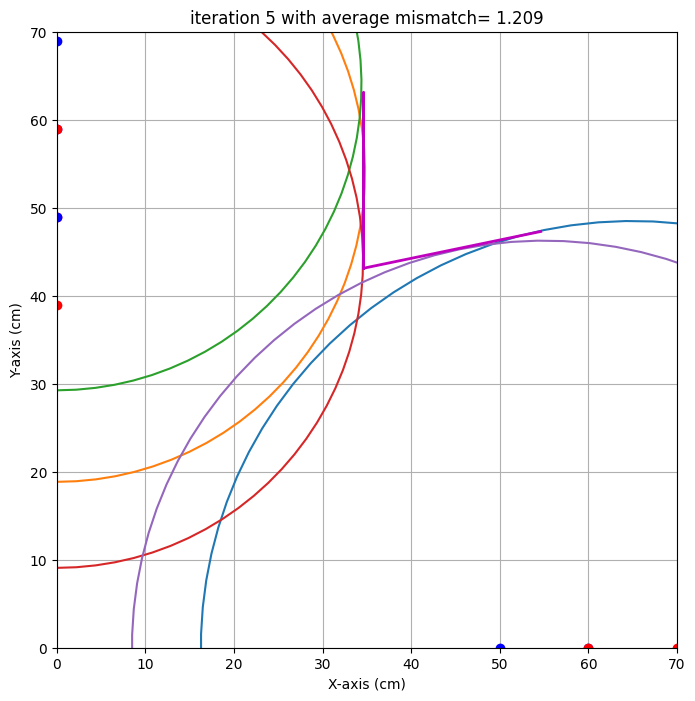

end iteration 5 with average mismatch= 1.209


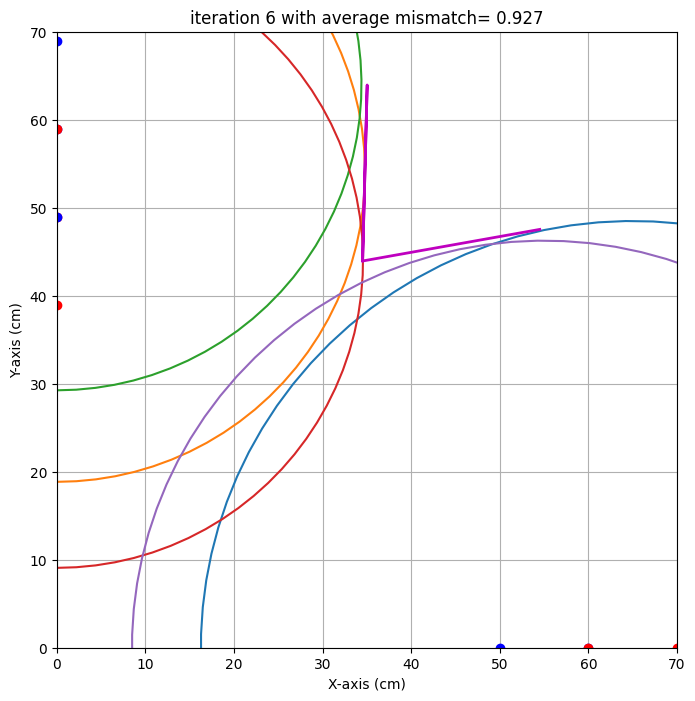

end iteration 6 with average mismatch= 0.927


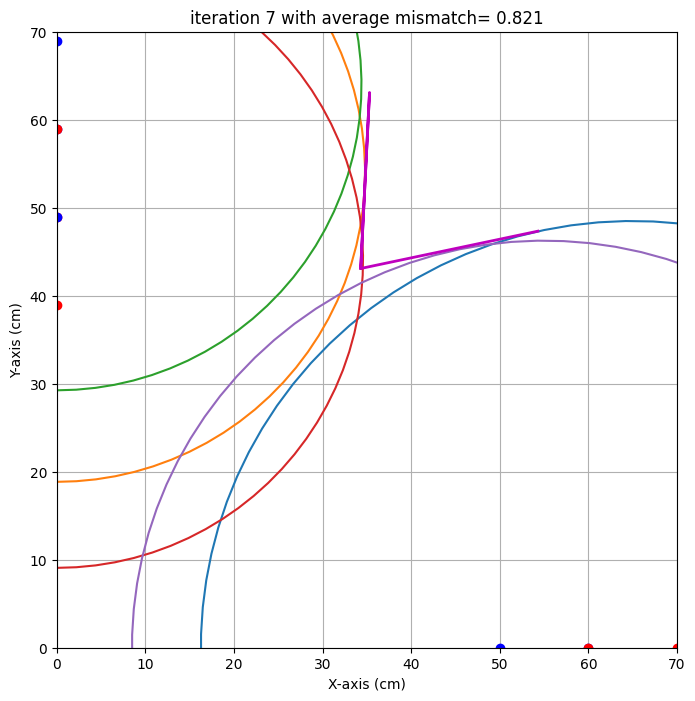

end iteration 7 with average mismatch= 0.821
end iteration 8 with average mismatch= 0.800
end iteration 9 with average mismatch= 0.798
end iteration 10 with average mismatch= 0.797
end iteration 11 with average mismatch= 0.797
end iteration 12 with average mismatch= 0.797
end iteration 13 with average mismatch= 0.797
end iteration 14 with average mismatch= 0.797
end iteration 15 with average mismatch= 0.797
end iteration 16 with average mismatch= 0.797
end iteration 17 with average mismatch= 0.797
end iteration 18 with average mismatch= 0.797
end iteration 19 with average mismatch= 0.797
end iteration 20 with average mismatch= 0.797
end iteration 21 with average mismatch= 0.797
end iteration 22 with average mismatch= 0.797
end iteration 23 with average mismatch= 0.797
end iteration 24 with average mismatch= 0.797
end iteration 25 with average mismatch= 0.797
end iteration 26 with average mismatch= 0.797
end iteration 27 with average mismatch= 0.797
end iteration 28 with average mismatc

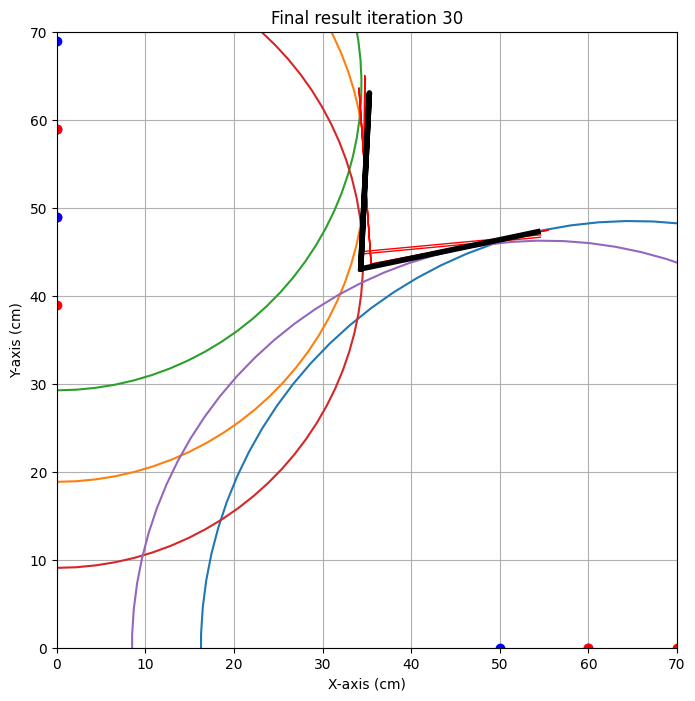

{'alpha': np.float64(11.920506102093011), 'alpha_eps': np.float64(6.547665231439405), 'beta': np.float64(2.806612868792854), 'beta_eps': np.float64(6.736452601136532), 'x0': np.float64(34.298152012341745), 'x0_eps': np.float64(1.1791738979253097), 'y0': np.float64(43.046327744519914), 'y0_eps': np.float64(1.9814238997560665)}


In [47]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [48]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

ChristophSmit 
x0 target is : 35.5. Gevonden waarde: 34.9 cm met een standaardafwijking van 0.6 cm 
y0 target is : 41.9. Gevonden waarde: 43.6 cm met een standaardafwijking van 1.2 cm 
alpha target is : 7.0. Gevonden waarde: 7.3 graden met een standaardafwijking van 6.4 graad 
beta target is : 0.0. Gevonden waarde: -1.1 graden met een standaardafwijking van 4.8 graad 

ShannonWerleman 
x0 target is : 35.5. Gevonden waarde: 33.7 cm met een standaardafwijking van 1.0 cm 
y0 target is : 41.9. Gevonden waarde: 41.7 cm met een standaardafwijking van 0.2 cm 
alpha target is : 7.0. Gevonden waarde: 10.2 graden met een standaardafwijking van 3.1 graad 
beta target is : 0.0. Gevonden waarde: 2.4 graden met een standaardafwijking van 6.8 graad 

CasperJansen 
x0 target is : 35.5. Gevonden waarde: 34.3 cm met een standaardafwijking van 1.2 cm 
y0 target is : 41.9. Gevonden waarde: 43.0 cm met een standaardafwijking van 2.0 cm 
alpha target is : 7.0. Gevonden waarde: 11.9 graden met een standaarda

## Opdracht 8: Iteratie1+ 14:51.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur:
<img src="iteratie1.jpeg" width="400">
<img src="iteratiefinal.jpeg" width="400">



## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  70   0  60   55.41
1  28   0  38   0   97.43
2  18   0  28   0  102.36


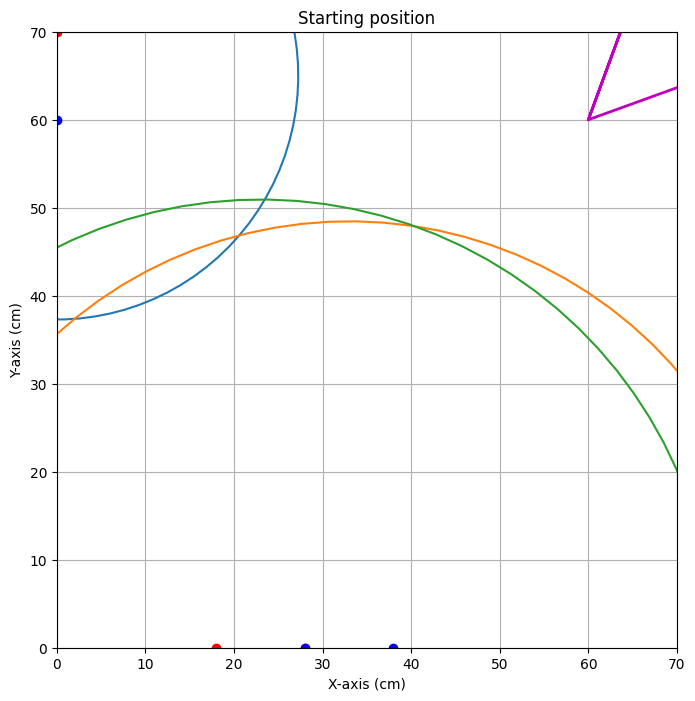


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.406


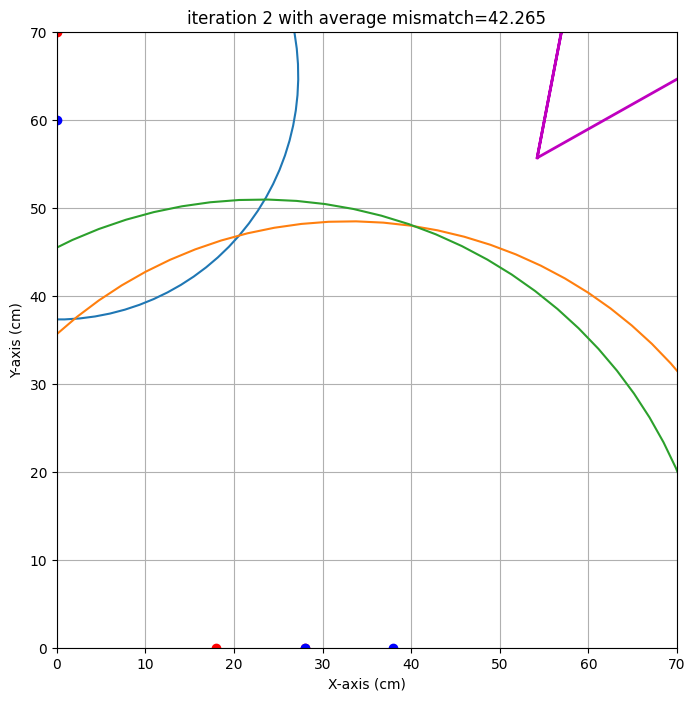

end iteration 2 with average mismatch=42.265


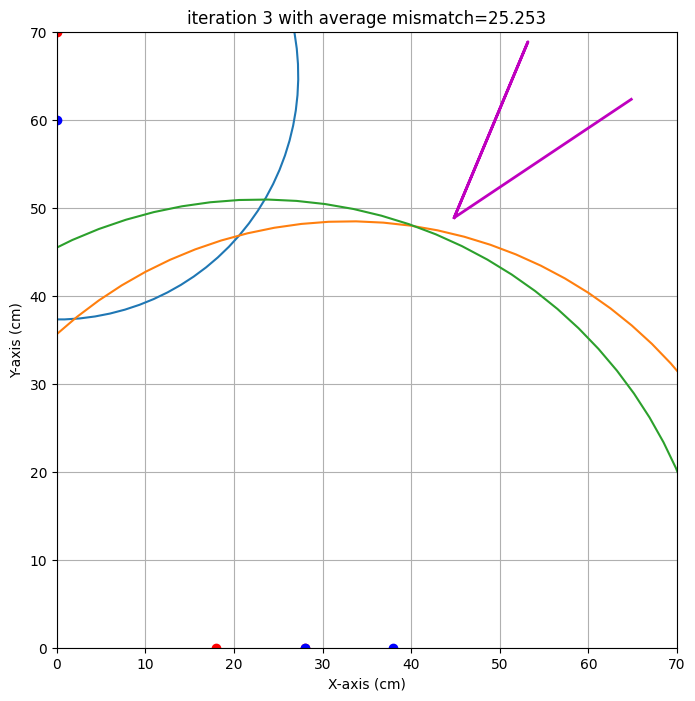

end iteration 3 with average mismatch=25.253


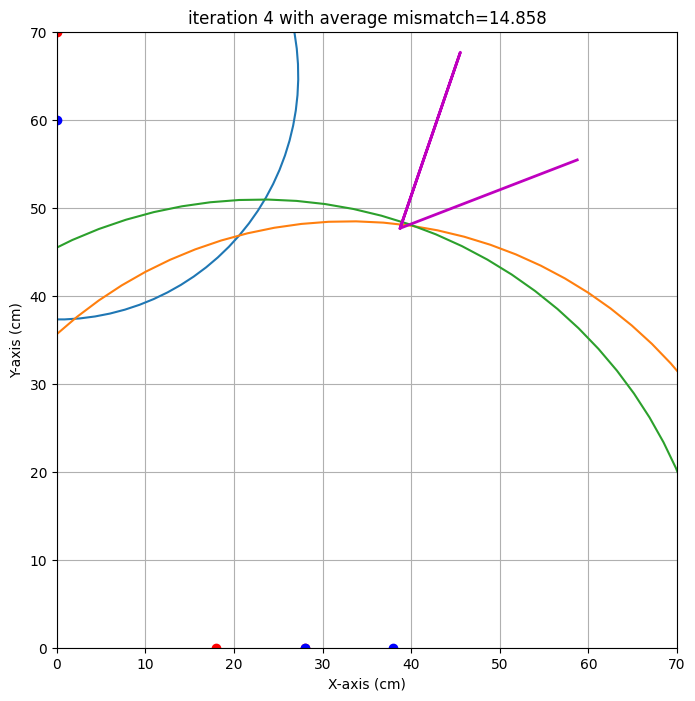

end iteration 4 with average mismatch=14.858


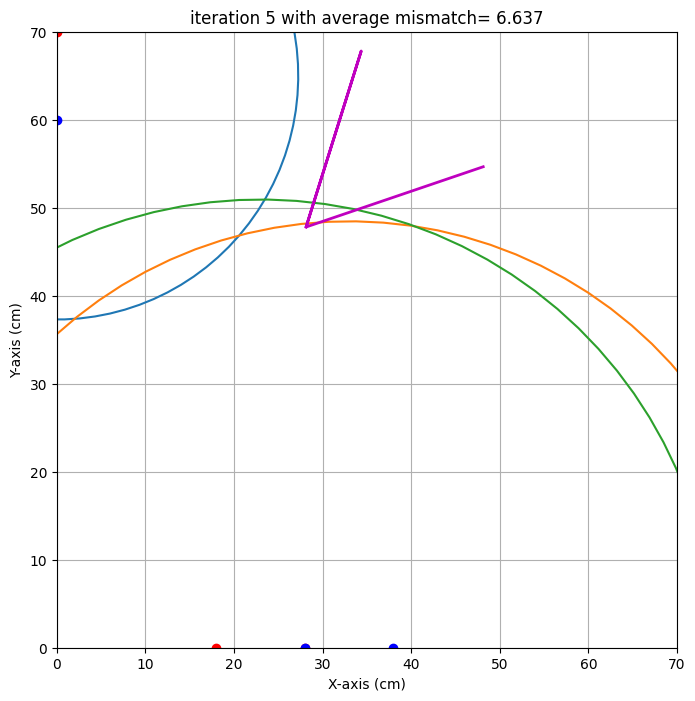

end iteration 5 with average mismatch= 6.637


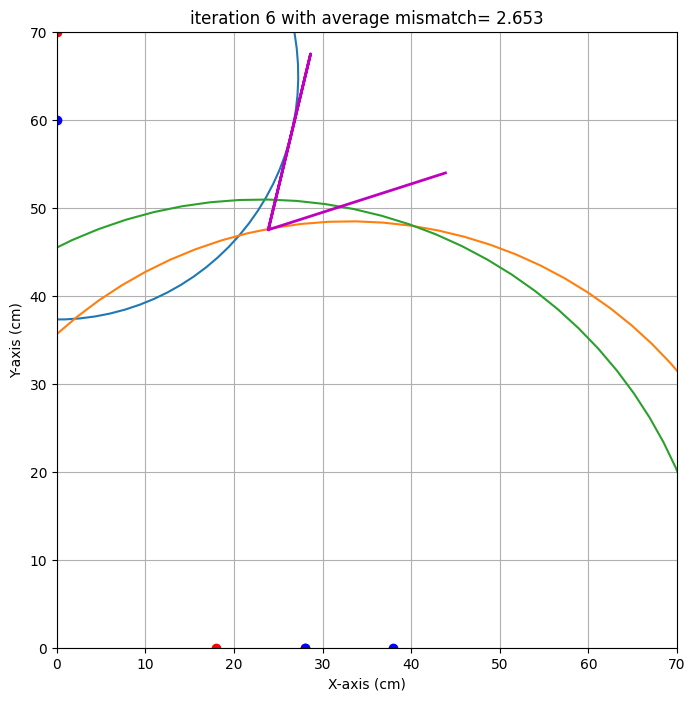

end iteration 6 with average mismatch= 2.653
end iteration 7 with average mismatch= 2.449


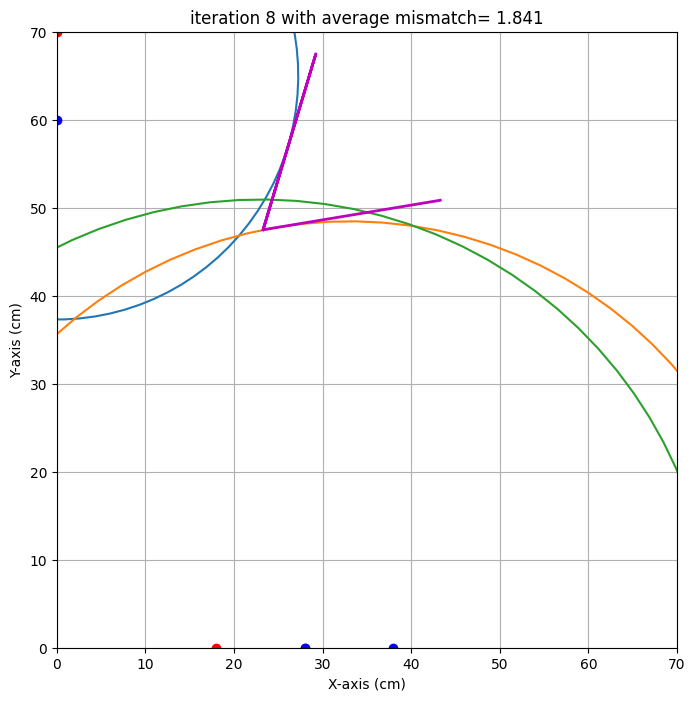

end iteration 8 with average mismatch= 1.841
end iteration 9 with average mismatch= 1.684
end iteration 10 with average mismatch= 1.684
end iteration 11 with average mismatch= 1.599
end iteration 12 with average mismatch= 1.575


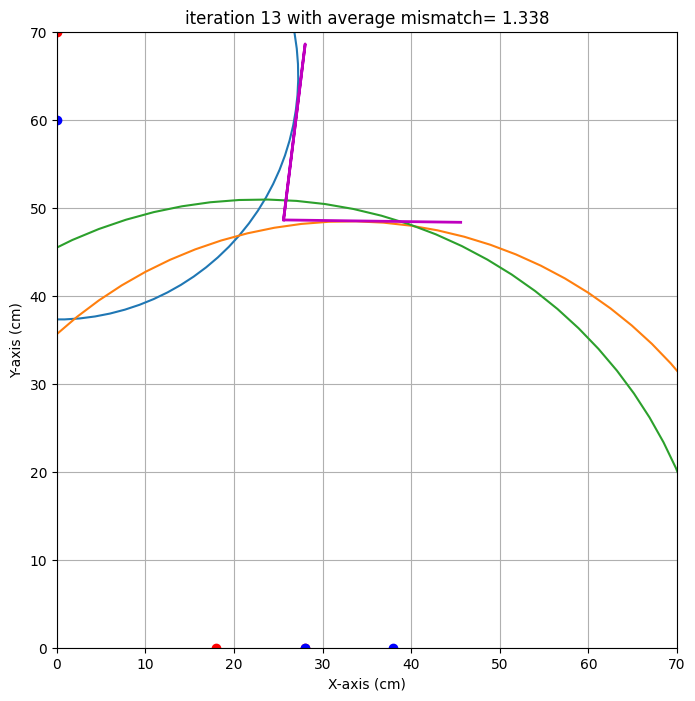

end iteration 13 with average mismatch= 1.338
end iteration 14 with average mismatch= 1.295


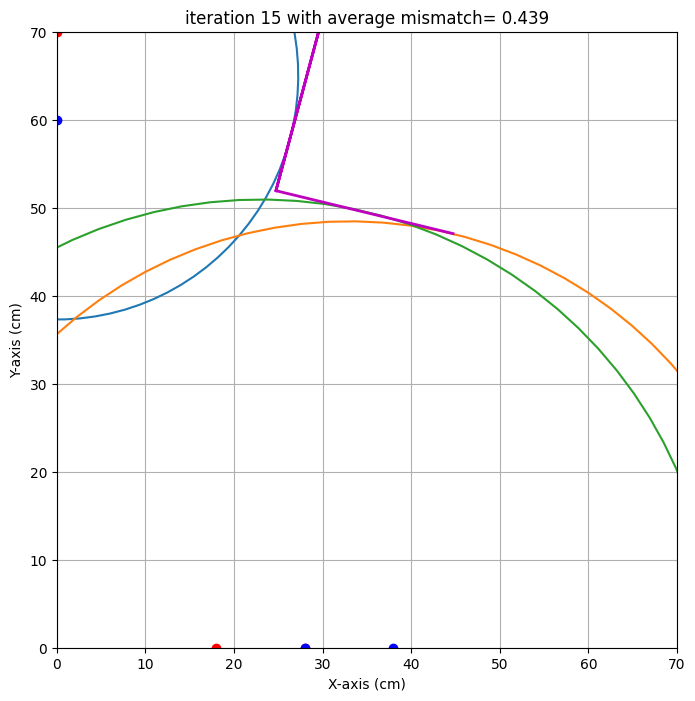

end iteration 15 with average mismatch= 0.439


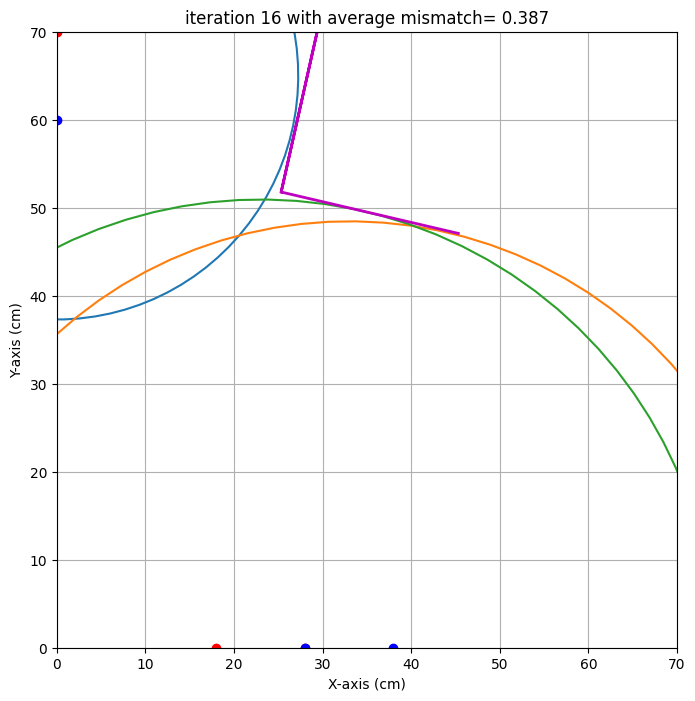

end iteration 16 with average mismatch= 0.387
end iteration 17 with average mismatch= 0.377


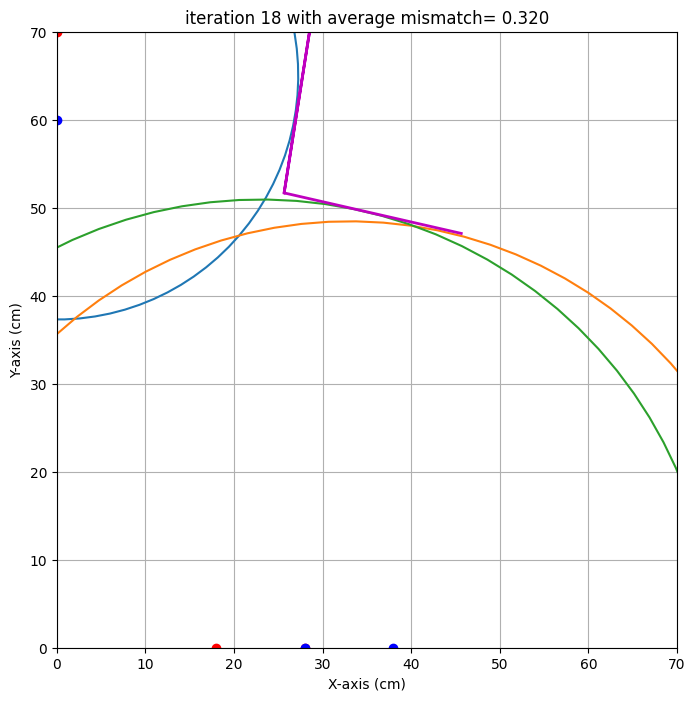

end iteration 18 with average mismatch= 0.320


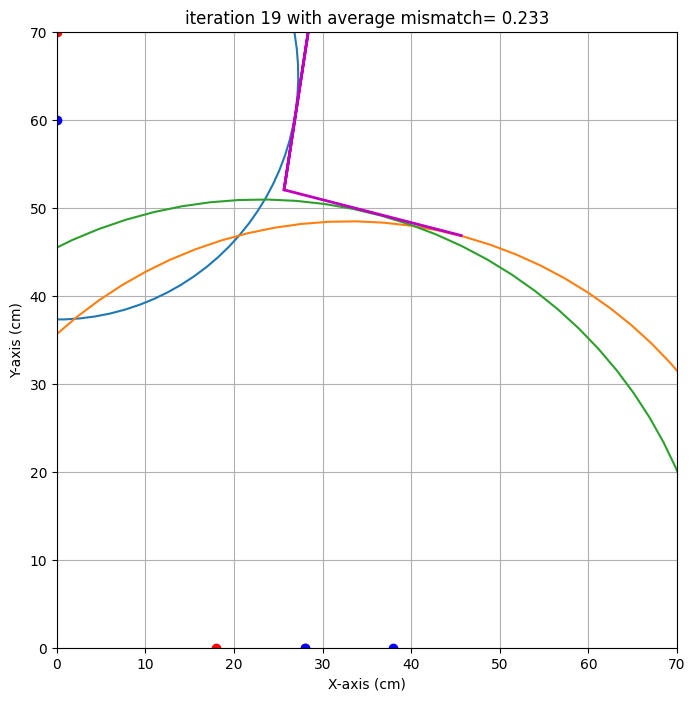

end iteration 19 with average mismatch= 0.233


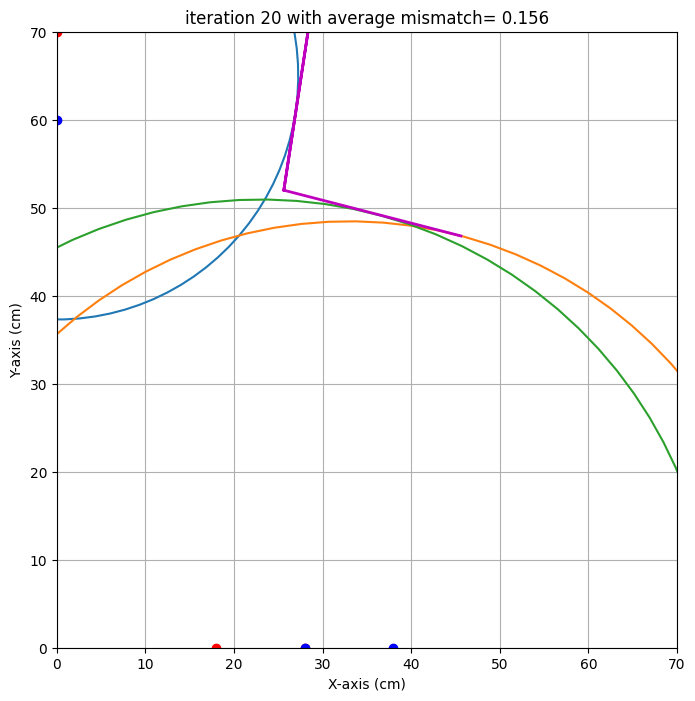

end iteration 20 with average mismatch= 0.156
end iteration 21 with average mismatch= 0.156
end iteration 22 with average mismatch= 0.155
end iteration 23 with average mismatch= 0.155
end iteration 24 with average mismatch= 0.155
end iteration 25 with average mismatch= 0.155
end iteration 26 with average mismatch= 0.155
end iteration 27 with average mismatch= 0.155
end iteration 28 with average mismatch= 0.155
end iteration 29 with average mismatch= 0.155
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.155
###############################################################################
end of iteration  30
Best alpha= -14.58 with uncertainty=   2.45
Best beta =   8.63 with uncertainty=  12.77
Best x0   =  25.62 with uncertainty=   3.14
Best y0   =  51.99 with uncertainty=   0.93
###############################################################################


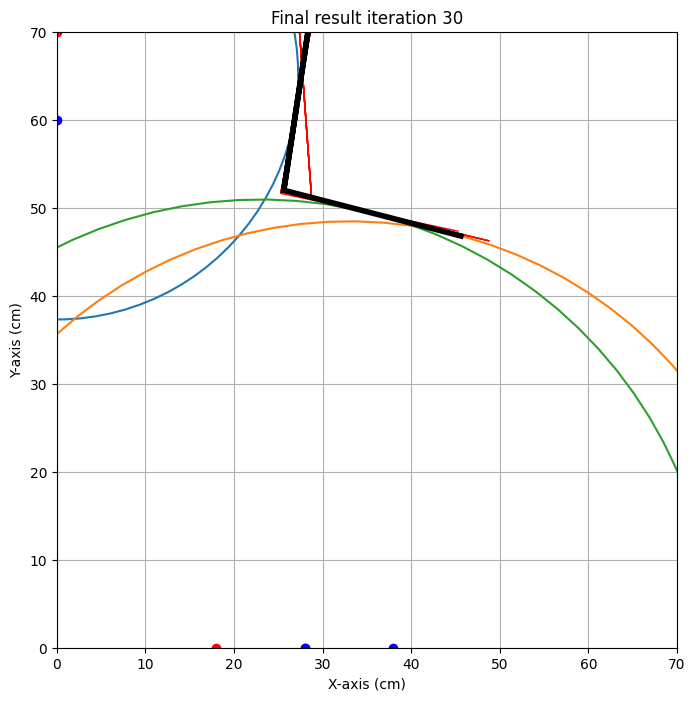

{'alpha': np.float64(-14.575550326560329), 'alpha_eps': np.float64(2.4545694224346146), 'beta': np.float64(8.63017372428583), 'beta_eps': np.float64(12.767287472732326), 'x0': np.float64(25.616506539672002), 'x0_eps': np.float64(3.1422693718988164), 'y0': np.float64(51.98685539869061), 'y0_eps': np.float64(0.9341385684170405)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  60   0  50  67.53
1   0  55   0  45  66.31
2   0  50   0  40  70.03
3   0  45   0  35  71.13
4   0  40   0  30  71.40
5  40   0  50   0  74.20
6  45   0  55   0  75.02
7  50   0  60   0  76.02
8  55   0  65   0  78.42


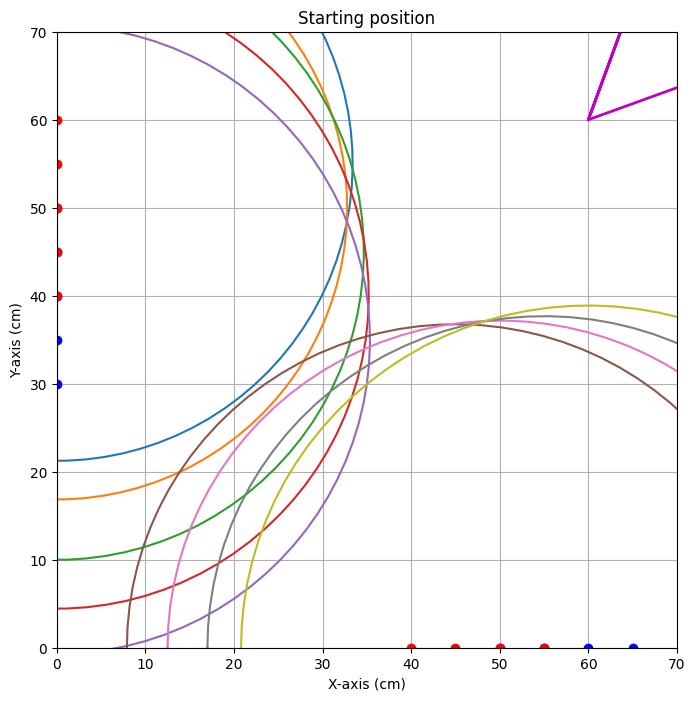


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.410


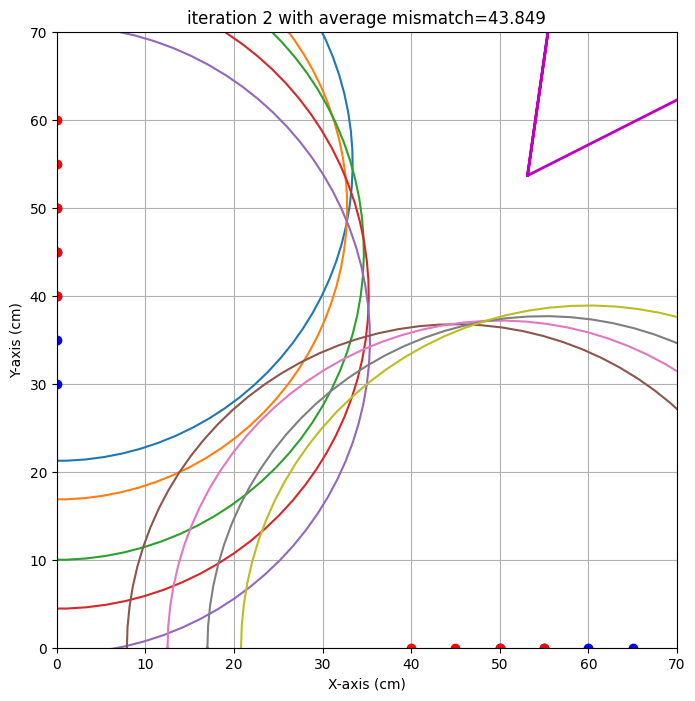

end iteration 2 with average mismatch=43.849


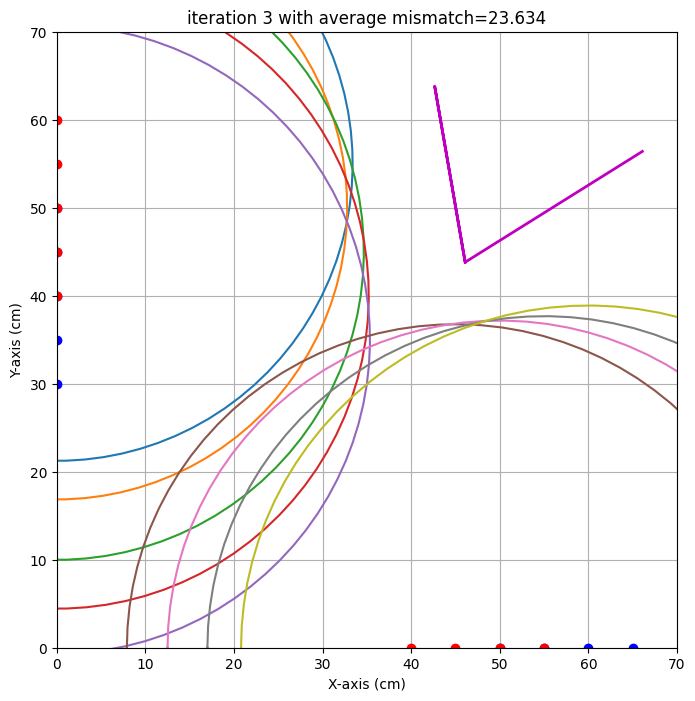

end iteration 3 with average mismatch=23.634


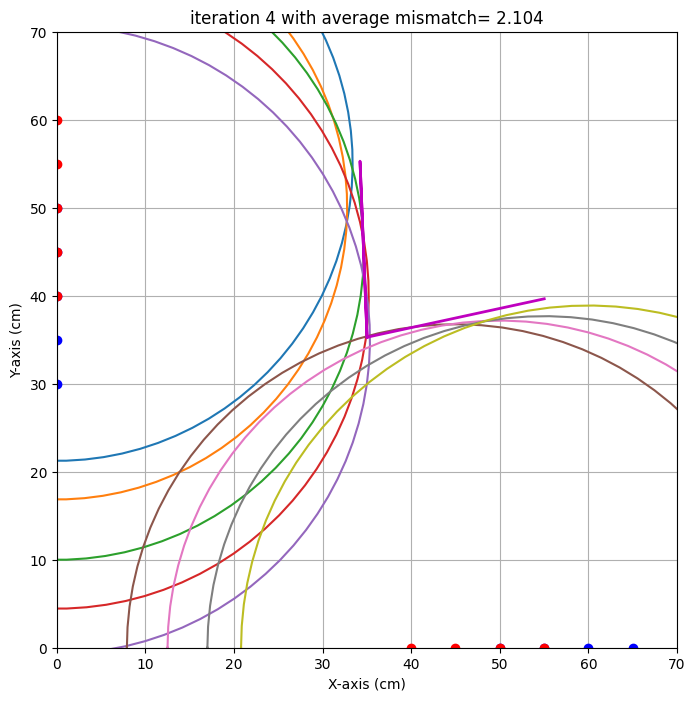

end iteration 4 with average mismatch= 2.104


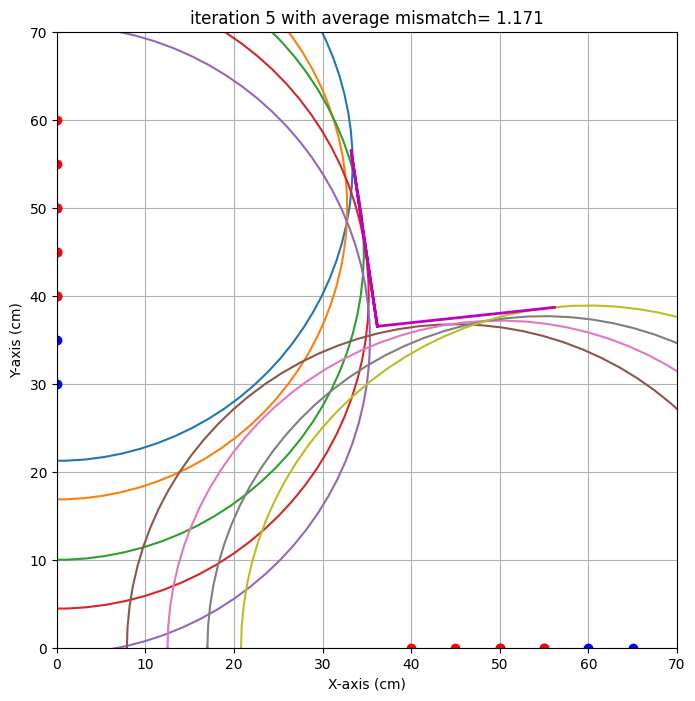

end iteration 5 with average mismatch= 1.171
end iteration 6 with average mismatch= 1.131
end iteration 7 with average mismatch= 1.127
end iteration 8 with average mismatch= 1.126
end iteration 9 with average mismatch= 1.126
end iteration 10 with average mismatch= 1.125
end iteration 11 with average mismatch= 1.125
end iteration 12 with average mismatch= 1.068
end iteration 13 with average mismatch= 1.067
end iteration 14 with average mismatch= 1.061
end iteration 15 with average mismatch= 1.057
end iteration 16 with average mismatch= 1.057
end iteration 17 with average mismatch= 1.057
end iteration 18 with average mismatch= 1.056
end iteration 19 with average mismatch= 1.032
end iteration 20 with average mismatch= 1.009
end iteration 21 with average mismatch= 1.004
end iteration 22 with average mismatch= 1.002
end iteration 23 with average mismatch= 1.001
end iteration 24 with average mismatch= 1.000
end iteration 25 with average mismatch= 1.000
end iteration 26 with average mismatch=

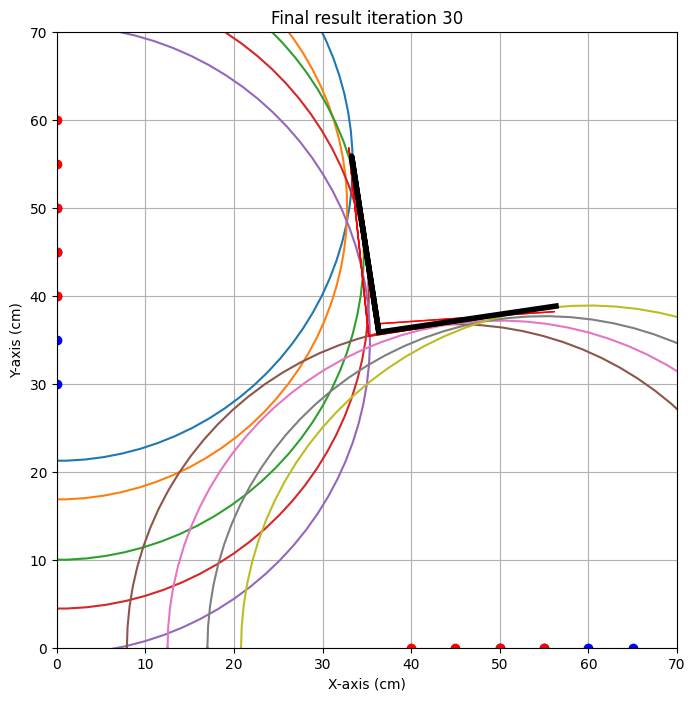

{'alpha': np.float64(8.44155562803313), 'alpha_eps': np.float64(4.48621844286155), 'beta': np.float64(-8.724189854828943), 'beta_eps': np.float64(2.6899132753125183), 'x0': np.float64(36.345646988031774), 'x0_eps': np.float64(1.134113848803679), 'y0': np.float64(35.854631269961075), 'y0_eps': np.float64(0.9506624657885894)}
locatie 1 
x0 target is : 25.7. Gevonden waarde: 25.6 cm met een standaardafwijking van 3.1 cm 
y0 target is : 52.8. Gevonden waarde: 52.0 cm met een standaardafwijking van 0.9 cm 
alpha target is : -15.0. Gevonden waarde: -14.6 graden met een standaardafwijking van 2.5 graad 
beta target is : 14.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 12.8 graad 

locatie 2 
x0 target is : 36.7. Gevonden waarde: 36.3 cm met een standaardafwijking van 1.1 cm 
y0 target is : 36.0. Gevonden waarde: 35.9 cm met een standaardafwijking van 1.0 cm 
alpha target is : 7.0. Gevonden waarde: 8.4 graden met een standaardafwijking van 4.5 graad 
beta target is : -6.0. Gevo

In [41]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':25.7,
                    'y0':52.8,
                    'alpha' : -15,
                    'beta' : 14},
           'locatie 2':{'x0':36.7,
                    'y0':36,
                    'alpha' :7,
                    'beta' : -6}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,55.41],
    #[0,60,0,50,ongeldig]
    [28,0,38,0,97.43],
    #[38,0,48,0,ongeldig]
    [18,0,28,0,102.36]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,70,0,60,ongeldig],
    [0,60,0,50,67.53],
    [0,55,0,45,66.31],
    [0,50,0,40,70.03],
    [0,45,0,35,71.13],
    [0,40,0,30,71.40],
    #[0,35,0,25,79.30],
    #[35,0,45,0,77.5],
    [40,0,50,0,74.2],
    [45,0,55,0,75.02],
    [50,0,60,0,76.02],
    [55,0,65,0,78.42],
    #[60,0,70,0,82.0]

    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  47.15
1   0  65   0  55  46.84
2   0  60   0  50  46.66
3   0  55   0  45  45.60
4   0  50   0  40  45.25
5  25   0  35   0  82.44
6  30   0  40   0  83.52
7  35   0  45   0  85.16
8  40   0  50   0  86.36
9  45   0  55   0  88.90


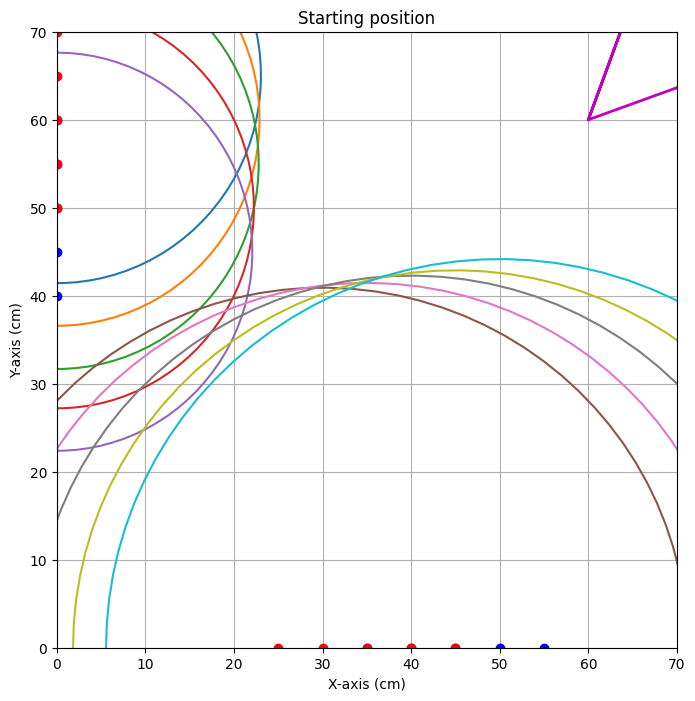


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.509


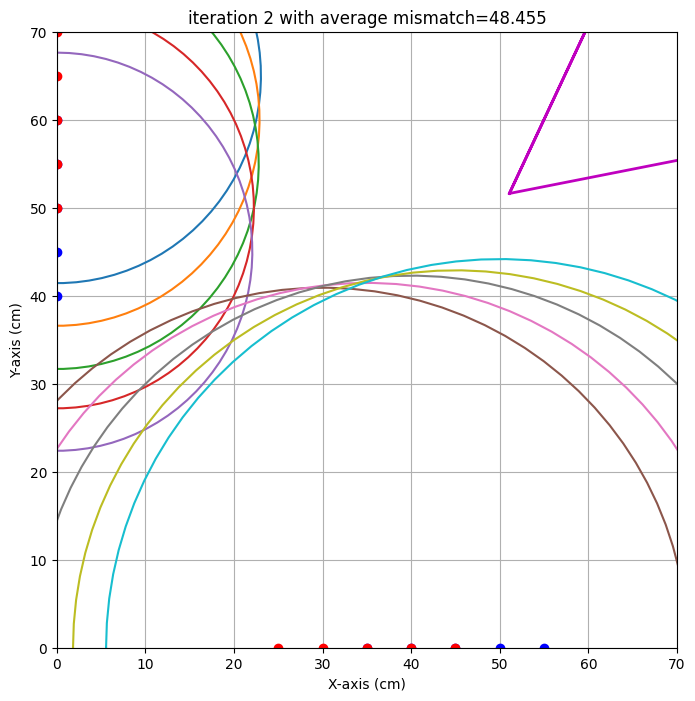

end iteration 2 with average mismatch=48.455


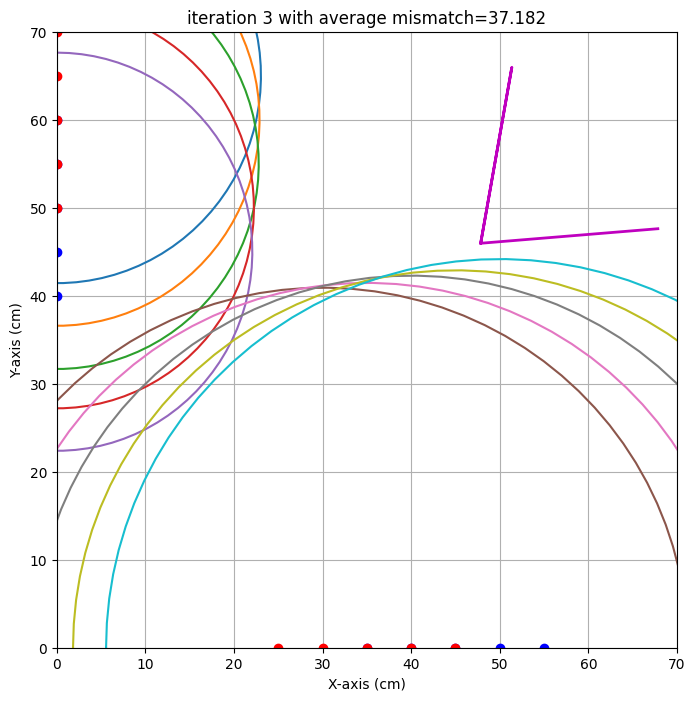

end iteration 3 with average mismatch=37.182


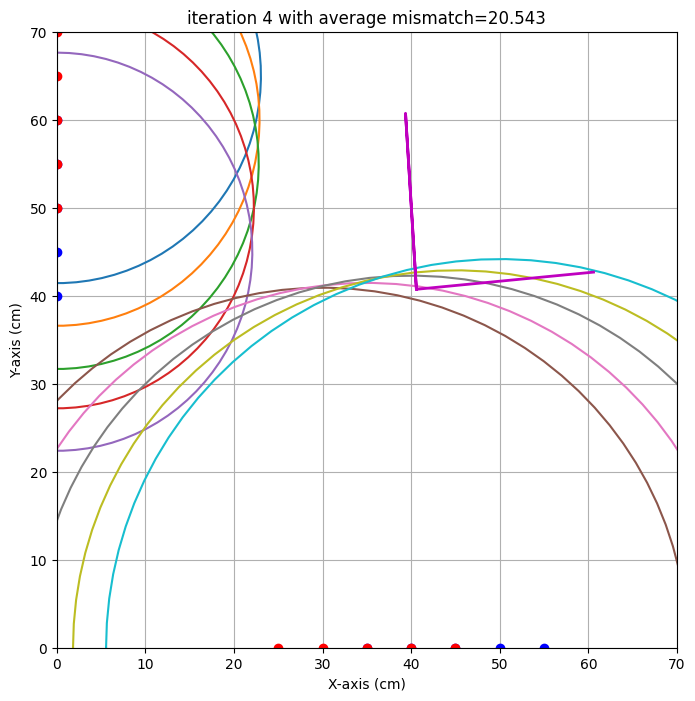

end iteration 4 with average mismatch=20.543


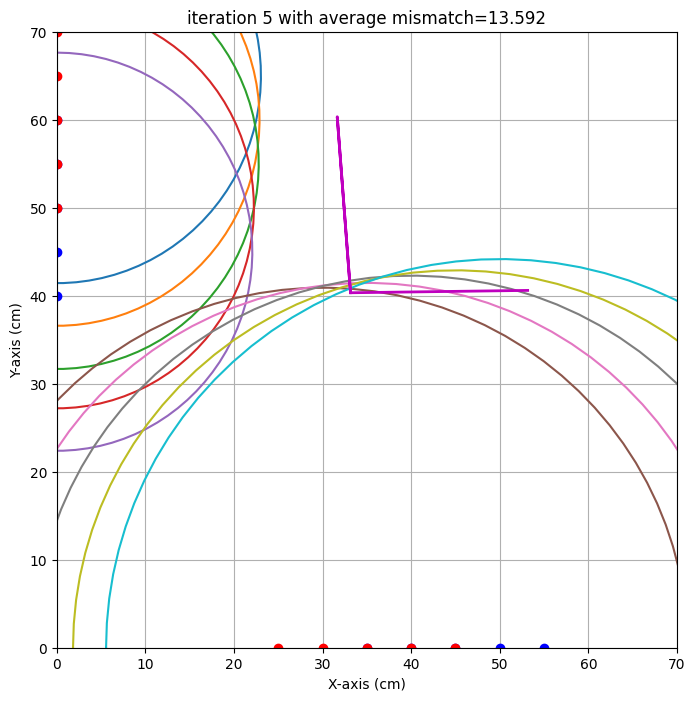

end iteration 5 with average mismatch=13.592


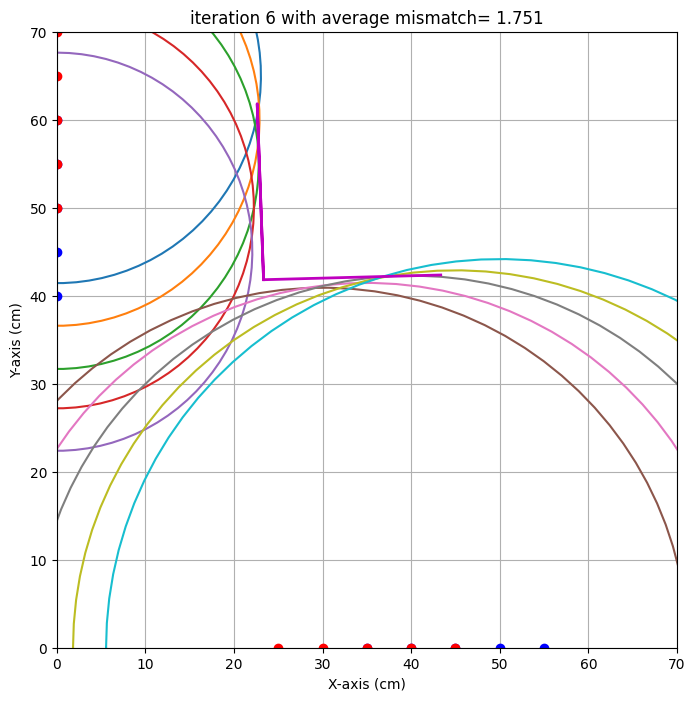

end iteration 6 with average mismatch= 1.751


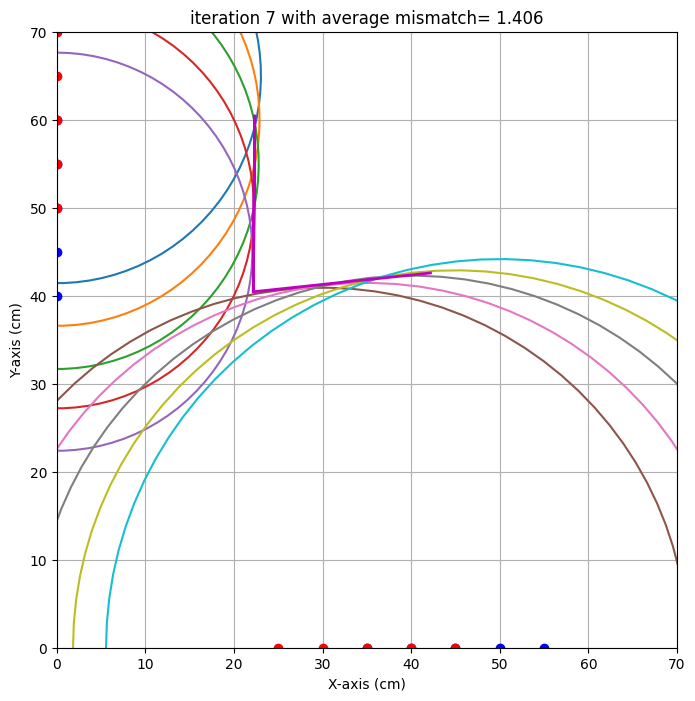

end iteration 7 with average mismatch= 1.406


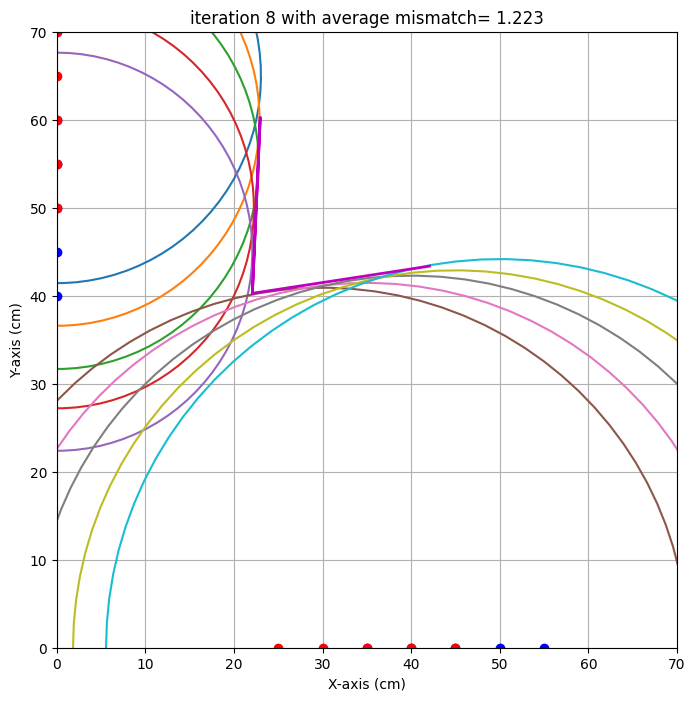

end iteration 8 with average mismatch= 1.223
end iteration 9 with average mismatch= 1.179
end iteration 10 with average mismatch= 1.139
end iteration 11 with average mismatch= 1.131
end iteration 12 with average mismatch= 1.126
end iteration 13 with average mismatch= 1.097
end iteration 14 with average mismatch= 1.093
end iteration 15 with average mismatch= 1.091
end iteration 16 with average mismatch= 1.091
end iteration 17 with average mismatch= 1.091
end iteration 18 with average mismatch= 1.091
end iteration 19 with average mismatch= 1.091
end iteration 20 with average mismatch= 1.091
end iteration 21 with average mismatch= 1.091
end iteration 22 with average mismatch= 1.091
end iteration 23 with average mismatch= 1.091
end iteration 24 with average mismatch= 1.091
end iteration 25 with average mismatch= 1.091
end iteration 26 with average mismatch= 1.091
end iteration 27 with average mismatch= 1.091
end iteration 28 with average mismatch= 1.091
end iteration 29 with average mismat

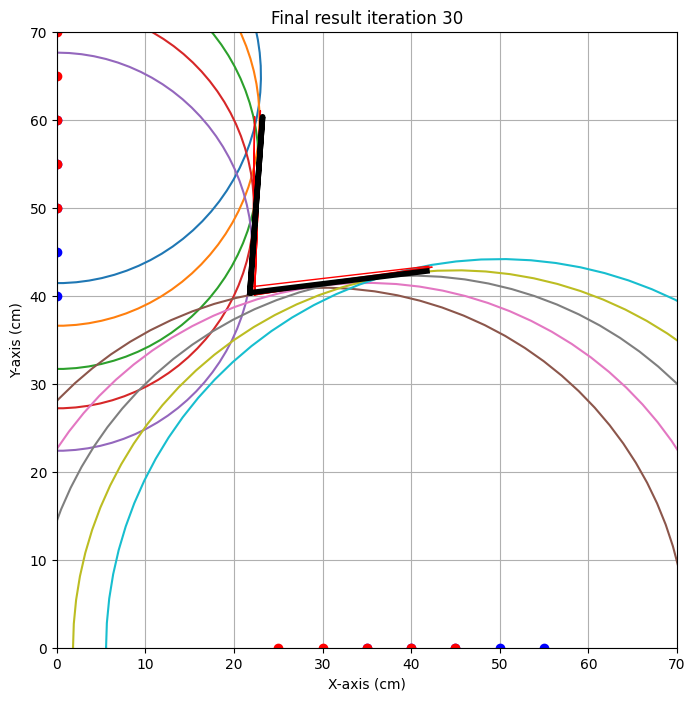

{'alpha': np.float64(7.03275011178642), 'alpha_eps': np.float64(1.9198233386719785), 'beta': np.float64(4.137570557621892), 'beta_eps': np.float64(3.4791727749071484), 'x0': np.float64(21.780460816008596), 'x0_eps': np.float64(0.5372895544545138), 'y0': np.float64(40.33959720908714), 'y0_eps': np.float64(0.681068192128329)}
test locatie 
x0 target is : 22.2. Gevonden waarde: 21.8 cm met een standaardafwijking van 0.5 cm 
y0 target is : 40.4. Gevonden waarde: 40.3 cm met een standaardafwijking van 0.7 cm 
alpha target is : 8.5. Gevonden waarde: 7.0 graden met een standaardafwijking van 1.9 graad 
beta target is : 4.0. Gevonden waarde: 4.1 graden met een standaardafwijking van 3.5 graad 



In [42]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  22.2,
                    'y0':  40.4,
                    'alpha' :  8.5,
                    'beta' :  4
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [0,70,0,60,47.15],
                    [0,65,0,55,46.84],
                    [0,60,0,50,46.66],
                    [0,55,0,45,45.60],
                    [0,50,0,40,45.25],
                    #[0,45,0,35,ongeldig]
                    [25,0,35,0,82.44],
                    [30,0,40,0,83.52],
                    [35,0,45,0,85.16],
                    [40,0,50,0,86.36],
                    [45,0,55,0,88.9]
                    #[50,0,60,0,ongeldig]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
## Stap 1:

<img src="Algoritme.jpeg" width="400">
<img src="algoritmechristoph.jpeg" width="400">
<img src="algorcasper.jpeg" width="400">

Dit zijn de drie algoritmes van ons alledrie.

## Stap 2:

<img src="iteratie1.jpeg" width="400">


Het algoritme van Christoph had te veel metingen dus de stapgrootte hebben we vergroot.

## Stap 3
<img src="iteratiefinal.jpeg" width="400">

We hebben twee algoritmes samengevoegd tot één algoritme, dit was het uiteindelijke algoritme. Het haalde de volgende waarden:

<img src="finaldata.png" width="400">